# setup

In [ ]:

! pip install sentinelhub  # extra dependencies for interacting with Amazon Web Services
! pip install s2cloudless

import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sentinelhub import CRS, BBox, DataCollection, MimeType, SentinelHubRequest, SHConfig, generate_evalscript, Geometry
from sentinelhub.api.catalog import get_available_timestamps

from s2cloudless import S2PixelCloudDetector, download_bands_and_valid_data_mask

# Dar valor a las siguientes variables para la ejecución en local:
CLIENT_ID = ""
CLIENT_SECRET = ""
INSTANCE_ID = ""
CAPA_FECHAS_ID = ""

config = SHConfig()

# CLIENT_ID and CLIENT_SECRET and INSTANCE_ID deben tener un valor válido
assert CLIENT_ID and CLIENT_SECRET and INSTANCE_ID and CAPA_FECHAS_ID
config.sh_client_id = CLIENT_ID
config.sh_client_secret = CLIENT_SECRET



In [2]:
# Variables que dependen del pantano de interés
bbox = BBox(bbox=[-1.82727781561789, 41.8733944002713, -1.78675590600686, 41.8837564288121], crs=CRS.WGS84)
geometry = Geometry(geometry={"type":"Polygon","coordinates":[[[-1.82727781561789,41.878836997648],[-1.82706061099506,41.8793910316484],[-1.82678427776792,41.8796379207089],[-1.8267768180961,41.8800685514024],[-1.82642537447412,41.8802598648753],[-1.82617844158665,41.8806380527725],[-1.82614655470031,41.8810247360922],[-1.82543288469845,41.881535289767],[-1.82390550456733,41.8819140643813],[-1.82244400558138,41.8814295004439],[-1.82169248623425,41.8814295729659],[-1.81975201370667,41.8808426844035],[-1.81935180843586,41.8810822729263],[-1.81889142551101,41.8809638457657],[-1.81770961331756,41.8818029429609],[-1.81794192849123,41.8811437986041],[-1.81747439224727,41.8811669513082],[-1.81544009979004,41.8819473181518],[-1.81537615307333,41.8827316637033],[-1.81529526493697,41.8824714388691],[-1.81478143545625,41.8821641473958],[-1.81321515692413,41.8823354730057],[-1.81270695832156,41.8830140476162],[-1.81290528275152,41.8835253802118],[-1.81278937249098,41.8837564288121],[-1.81277806268346,41.883480857389],[-1.8122199798341,41.8828389804146],[-1.81214536293955,41.8823638613245],[-1.81120590421546,41.8824885712919],[-1.81096625650443,41.8826861040226],[-1.80966922247806,41.8821837586669],[-1.80913373180124,41.8824093077282],[-1.80903349932946,41.8828505706354],[-1.80926700515388,41.8831684218045],[-1.80887135846995,41.882985752785],[-1.80849363922767,41.8825331981089],[-1.80782983754413,41.8827851743272],[-1.80754896359537,41.8830833830551],[-1.80766280842421,41.882724078224],[-1.80816970800451,41.8821383700962],[-1.80812440206062,41.8819662306239],[-1.80697954470102,41.8815603363968],[-1.80644983192242,41.881594891384],[-1.80620458724806,41.881353327432],[-1.80553516301825,41.8811798034405],[-1.80478722669033,41.8817747810412],[-1.8047714606654,41.8821647313033],[-1.80448304441478,41.8818655050751],[-1.8045702913307,41.8809824092244],[-1.80439240437451,41.8809129497498],[-1.80338843588124,41.880930800669],[-1.80242091254617,41.8806542077364],[-1.80231133447572,41.8809671551384],[-1.80248106547165,41.8814238262763],[-1.80233655446581,41.8819055827932],[-1.80196261114899,41.8814340285499],[-1.80102987340036,41.8819104804219],[-1.80133884977586,41.8811024604306],[-1.80124510949152,41.8810009596878],[-1.80057983054835,41.8810946463983],[-1.8009589055566,41.8805299037574],[-1.80082217244091,41.880376149344],[-1.80009383695977,41.8802430838122],[-1.80001865691101,41.8801117181537],[-1.79973251752382,41.8802351537555],[-1.79982218955014,41.8803640060035],[-1.7996450567229,41.8805319458118],[-1.79890432846051,41.8808159531194],[-1.79910058217793,41.8802827647404],[-1.79903867785009,41.8796713709064],[-1.79865510127162,41.8796905758558],[-1.79851470331592,41.8795314799428],[-1.79827554450873,41.8796962972244],[-1.79826131350684,41.8799661150494],[-1.79810925650187,41.8798642175742],[-1.79806567447339,41.8801393311783],[-1.79740674119285,41.8806149905623],[-1.79758209939706,41.8799970073255],[-1.79726740311528,41.8791548765734],[-1.79666691901402,41.8793225585723],[-1.79629048646262,41.8790609927122],[-1.79588907016899,41.8790608839296],[-1.79583189437719,41.8798596999822],[-1.79527531450318,41.8806087468554],[-1.79513283759495,41.8797185158501],[-1.79427004716887,41.8801490959866],[-1.79430869413544,41.8796666299033],[-1.79388610532022,41.8796037776323],[-1.79448043157457,41.8790513270599],[-1.79418587413483,41.8786675570496],[-1.79362738343901,41.8786719576701],[-1.79338362649472,41.8783130272995],[-1.79267358583723,41.8784717482201],[-1.79243667442283,41.8778482628759],[-1.79159094158416,41.8777606361684],[-1.79101089664379,41.877448491317],[-1.79082433361377,41.8777854890534],[-1.79053541889838,41.8778298086641],[-1.79012429318485,41.8786343997579],[-1.79032926872101,41.8794731892807],[-1.79001708861323,41.8790345311159],[-1.78941471594915,41.879355086099],[-1.7896346234327,41.8786773474346],[-1.78940255422556,41.8782613000913],[-1.78878882844704,41.8783087977463],[-1.7891183673016,41.8776237950861],[-1.78817905156632,41.8777292250975],[-1.787588452025,41.8779842859756],[-1.78675590600686,41.8747519580797],[-1.78738772590401,41.8744153166891],[-1.78786772210441,41.8745495541067],[-1.78850868072584,41.8743712082576],[-1.78964644204165,41.8744307721619],[-1.78988636765576,41.8742033846321],[-1.78989056943686,41.8738597399055],[-1.79047869853603,41.873822778178],[-1.79084145191376,41.8733944002713],[-1.79127514848517,41.874646417023],[-1.79324331041029,41.8751399372827],[-1.7943505019211,41.874424719589],[-1.79433424146509,41.8754746343384],[-1.79517337956745,41.875785817354],[-1.79576978856021,41.8756535089737],[-1.79573272391819,41.8759969317443],[-1.79589112552326,41.8761806504208],[-1.79683261329047,41.8764898142374],[-1.7971950009072,41.8764076990372],[-1.7982867932155,41.8754496251635],[-1.79875103562675,41.8747763101292],[-1.79874035377039,41.8756599195633],[-1.7984170875702,41.8764433406224],[-1.79850282002217,41.8765883782049],[-1.80000762772688,41.8770922501765],[-1.80042065573986,41.8770377549775],[-1.80080329277687,41.8773949038439],[-1.80134720443857,41.8773794729995],[-1.80148628961315,41.8776477114123],[-1.80190721941164,41.8778578643629],[-1.80212642778321,41.8778374536616],[-1.80374254044806,41.8766646325469],[-1.80343895877661,41.8770280651748],[-1.80318542283659,41.8777791853363],[-1.80313159994431,41.8780161349158],[-1.80326157705146,41.8781205778189],[-1.80592253249243,41.8784003120156],[-1.80665467814352,41.8782142784239],[-1.8067069369327,41.8784191570135],[-1.80703681175234,41.8786068883906],[-1.80860897177942,41.8789801476742],[-1.80913883743092,41.8789208168677],[-1.81018506745297,41.878104172331],[-1.80982864912023,41.8792227938857],[-1.80992452066216,41.8794497560846],[-1.81184655265018,41.8798744740862],[-1.81240968416889,41.8797745507224],[-1.81253505196819,41.8799744175929],[-1.81324317252286,41.8796600263133],[-1.81370934357197,41.8791286002685],[-1.81462435427787,41.8786622906009],[-1.8143027804954,41.8789602878803],[-1.81421005048142,41.8795805519189],[-1.81700225418677,41.8792528868237],[-1.81781714061544,41.8785349516061],[-1.81797828299946,41.8788988505855],[-1.81831030230912,41.8790400190651],[-1.821061539124,41.8793032747969],[-1.8216802149523,41.8789386511012],[-1.82180207444042,41.8794476169993],[-1.82220304645525,41.8797477582006],[-1.82332933155177,41.8799276418415],[-1.82415247938706,41.879841305858],[-1.82491415612036,41.8794460256712],[-1.82727781561789,41.878836997648]]]}, crs=CRS.WGS84)
size = [512, 175.828]

Funciones y constantes básicas:

In [3]:
def apiReqRez(data_collection, fecha, evalscript):
  """
  Envía una solicitud a la API de Sentinel Hub y recupera datos geoespaciales.
  Args:
    data_collection (DataCollection): La colección de datos (satélite) de interés (por ejemplo, DataCollection.SENTINEL2_L2A).
    fecha (str): Fecha en formato "YYYY-MM-DD" para la que tiene que existir una imagen para la misión especificada en 'data_collection'. Si no la solicitud fallará
    evalscript (str): El Evalscript utilizado para hacer la solicitud a la API. Ver https://docs.sentinel-hub.com/api/latest/evalscript/.
  Returns:
    numpy.ndarray: La respuesta de la API. Si ha sido exitosa, un numpy.ndarray con la lectura satelital.
  """
  request = SentinelHubRequest(
      evalscript=evalscript,
      input_data=[
          SentinelHubRequest.input_data(
              data_collection=data_collection,
              time_interval=fecha
              )
          ],
      responses=[
          SentinelHubRequest.output_response("default", MimeType.TIFF),
      ],

      bbox=bbox,
      geometry=geometry,
      size=size,

      config=config,
  )

  response = request.get_data() # API call

  return response[0] # el [0] porque devuelve lista de responses

# Varios evalscripts básicos necesarios

DM_EVALSCRPT = '''
    //VERSION=3

    function setup() {
        return {
            input: [{
                bands: ["dataMask"],
                units: ["DN"]
            }],
            output: {
              bands: 1,
              sampleType: "UINT8"
            }
        }
    }

    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }

    function evaluatePixel(sample) {
        return [sample.dataMask];
    }

  '''

NUBES_EVALSCRPT = '''
    //VERSION=3

    function setup() {
        return {
            input: [{
                bands: ["B01", "B02", "B04", "B05", "B08", "B8A", "B09", "B10", "B11", "B12"],
                units: ["REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE"]
            }],
            output: {
              bands: 10,
              sampleType: "FLOAT32"
            }
        }
    }

    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }

    function evaluatePixel(sample) {
        return [sample.B01, sample.B02, sample.B04, sample.B05, sample.B08, sample.B8A, sample.B09, sample.B10, sample.B11, sample.B12];
    }

  '''

AGUA_EVALSCRPT = '''
  //VERSION 3
    function setup() {
        return {
            input: [{
              bands: ["B03", "B08"],
              units: ["REFLECTANCE", "REFLECTANCE"]
            }],
            output: {
              bands: 1,
              sampleType: "FLOAT32"
            }

        }
    }

    //para preservar el factor de normalización
    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }


    function evaluatePixel(samples) {
        return[index(samples.B03, samples.B08)];
    }


  '''

ALLBANDS_EVALSCRPT = '''
    //VERSION=3

    function setup() {
        return {
            input: [{
                bands: ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"],
                units: ["REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE"]
            }],
            output: {
              bands: 12,
              sampleType: "FLOAT32"
            }
        }
    }

    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }

    function evaluatePixel(sample) {
        return [sample.B01, sample.B02, sample.B03, sample.B04, sample.B05, sample.B06, sample.B07, sample.B08, sample.B8A, sample.B09, sample.B11, sample.B12];
    }

  '''

# Funciones utiles

In [4]:
# Para conseguir las fechas con imágenes disponibles hay que usar una configuration instance
# (se crean en https://apps.sentinel-hub.com/dashboard/#/configurations) y una de sus capas, para la que qiueras comprobar las fechas

from sentinelhub.api.ogc import OgcImageService, OgcRequest
from sentinelhub.constants import ServiceType

def obtencionFechas(intervalo):
  """
  Obtiene una lista de fechas para un intervalo de tiempo en las que se ha hecho una lectura
  satelital con las características de la capa creada en el dashboard de Sentinel Hub.
  Args:
    intervalo (tuple): Una tupla que especifica el intervalo de tiempo (fecha_inicio, fecha_fin)
              en el formato ('YYYY-MM-DD', 'YYYY-MM-DD').
  Returns:
    list: Una lista ordenada de fechas únicas (cadenas en formato 'YYYY-MM-DD')
        que representan fechas válidas dentro del intervalo especificado.
  """
  ois_config = config.copy() # creamos una config nueva
  ois_config.instance_id = INSTANCE_ID # hace falta una conf. instance en la que este la capa (layer) q usamos para preguntar por las fechas
  ois_config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
  ois_config.sh_base_url = "https://sh.dataspace.copernicus.eu"
  ois = OgcImageService(config=ois_config)

  request = OgcRequest(
      layer = CAPA_FECHAS_ID, # el nombre que le he puesto a la capa
      bbox = bbox,
      data_collection = DataCollection.SENTINEL2_L2A,
      time = intervalo,
      service_type = ServiceType.WMS,
      config = ois_config,
      size_x = int(np.ceil(size[0])),
      size_y = int(np.ceil(size[1])),
      )
  response = ois.get_dates(request)
  fechas = [dt_obj.strftime('%Y-%m-%d') for dt_obj in response] # lista de fechas validas en formato 'yyyy-mm-dd'
  fechas = list(set(fechas)) # quitamos duplicados
  fechas.sort() # ordenamos

  return fechas

En la celda siguiente en la funcion `curvasEnFechas(fechas)` se devuelve 'rezDf', en el que en el que para cada fecha en '`fechas`' se almacena la media de cada banda de la imagen tomada ese día, para todas las fechas en las que el nº de px con agua y sin nubes están por encima de un minimo

In [5]:
# Calculo de nº minimio de px validos (sin agua o nubes) en una img para tenerla en cuenta
aquaThres = 0.5 # se asumirán con agua los px cuyo indice en la mascara de agua > aquaThres
dataMask = apiReqRez(DataCollection.SENTINEL2_L2A, "2024-02-22", DM_EVALSCRPT)
todasBandasNames = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12']

# minPrctgPx es el % min de px del pantano que tienen que ser validos para no descartar la imagen
# rezEvalscript es el que se usará para hacer la apicall cuyo resultado será devuelto tras aplicar las mascaras de aguaynubes
# noms_bandas es un array con el nombre, en orden, de las bandas que se devuelven segun rezEvalscript
def curvasEnFechas(fechas, minPrctgPx = .01, rezEvalscript=ALLBANDS_EVALSCRPT, noms_bandas=todasBandasNames):
  """
    Calcula las curvas de valores promedio de las lecturas de las bandas especificadas para un conjunto de fechas,
    considerando únicamente los píxeles válidos (sin nubes y con agua) dentro de la geometria descrita en `dataMask`.
    Parámetros:
    -----------
    fechas : list
      Lista de fechas para las cuales existan lecturas de la misión Sentinel-2. En formato "YYYY-MM-DD".
    minPrctgPx : float, opcional
      Porcentaje mínimo de píxeles válidos (válido = no está cubierto por nubes y su índice NDWI > `aquaThres`)
      requeridos para considerar una lectura individual como válida. Por defecto es 0.01 (1%).
    rezEvalscript : str, opcional
      Evalscript utilizado para obtener los datos de las bandas que cuyas curvas se quieran obtener.
      Por defecto es `ALLBANDS_EVALSCRPT`.
    noms_bandas : list, opcional
      Lista con los nombres de las bandas a procesar. Por defecto es `todasBandasNames`.
    Devuelve:
    --------
    rezDf : pandas.DataFrame
      DataFrame con las fechas como índice y las bandas como columnas.
      Cada columna representa la curva de valores promedio, para cada fecha, de las lecturas de una banda.
      Si una fecha no tiene suficientes píxeles válidos, se asigna NaN.
    """
  minValidPx = int(np.count_nonzero(dataMask)*minPrctgPx) # nº min de px validos del pantano

  # Df para guardar los resultados indexado para que en las fechas sin imagen valida haya NaN
  rezDf = pd.DataFrame(index=fechas, columns=noms_bandas)

  # Procesado
  for fecha in fechas:
    # Comprobacion de que hay suficientes px sin nubes
    nubesData = apiReqRez(DataCollection.SENTINEL2_L1C, fecha, NUBES_EVALSCRPT)
    cloud_detector = S2PixelCloudDetector(threshold=0.4, average_over=4, dilation_size=2, all_bands=False) #OJO: Si en NUBES_EVALSCRPT no estan todas las bandas hay q cambiar param 'all_bands'
    cloudMask = cloud_detector.get_cloud_masks(nubesData[np.newaxis, ...])[0]
    cloudMasknt = ~cloudMask & dataMask # 1o: se invierte cloudmask para q zonas sin nubes = 1; 2o se aplica dataMask para poner px fuera del pantano = 0
    nPxSinNubes = int(np.count_nonzero(cloudMasknt))
    if nPxSinNubes < minValidPx:
      continue # marcar fecha invalida

    else:
      # Comprobacion de que hay suficientes px con agua
      aguaData = apiReqRez(DataCollection.SENTINEL2_L2A, fecha, AGUA_EVALSCRPT)
      aquaMask = np.where(aguaData > aquaThres, 1, 0)
      nPxSinNubesOAgua = int(np.count_nonzero(cloudMasknt & aquaMask))
      if nPxSinNubesOAgua < minValidPx:
        continue # marcar fecha invalida
      else:
        # Se calcula y guarda el promedio de cada banda
        allBandsData = apiReqRez(DataCollection.SENTINEL2_L2A, fecha, rezEvalscript)
        bandas = allBandsData.transpose(2, 0, 1) # la API req devuelve (x,y,12) siendo x,y las dims de la img

        for i, banda in enumerate(bandas):
          cloudNaquaMask = aquaMask & cloudMasknt
          pxValidos = banda[cloudNaquaMask == 1] # array de los px validos (sin nubes y con agua)
          rezDf.loc[fecha, noms_bandas[i]] = np.mean(pxValidos)# guardamos la media de los valores px validos

  return rezDf

# curvas por periodo

In [ ]:
#Los episodios son detectados en las fechas 4/7/18, 10/7/20 y 10/9/20
fechas_eventos = [
    dt.datetime(2018, 7, 4),  # 4/7/18
    dt.datetime(2020, 7, 10), # 10/7/20
    dt.datetime(2020, 9, 10)  # 10/9/20
]
intervaloProb1 = ('2018-05-04', '2018-08-04')
intervaloProb2 = ('2020-05-10', '2020-08-10')
intervaloProb3 = ('2020-07-10', '2020-10-10')

curvas1erProb = curvasEnFechas(obtencionFechas(intervaloProb1))
curvas2oProb = curvasEnFechas(obtencionFechas(intervaloProb2))
curvas3erProb = curvasEnFechas(obtencionFechas(intervaloProb3))

In [ ]:
noms_bandas = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12']
curvas = [curvas1erProb,curvas2oProb,curvas3erProb]

# preprocesamiento dfs para poder usar interpolate
orden = 2 # la spline interpolation se hace con polys de este grado
for df in curvas:
  df.index = pd.to_datetime(df.index)
  for column in noms_bandas:
    df[column] = pd.to_numeric(df[column], errors='coerce')

curvas_inter = [df.interpolate(method='spline', order=orden) for df in curvas]


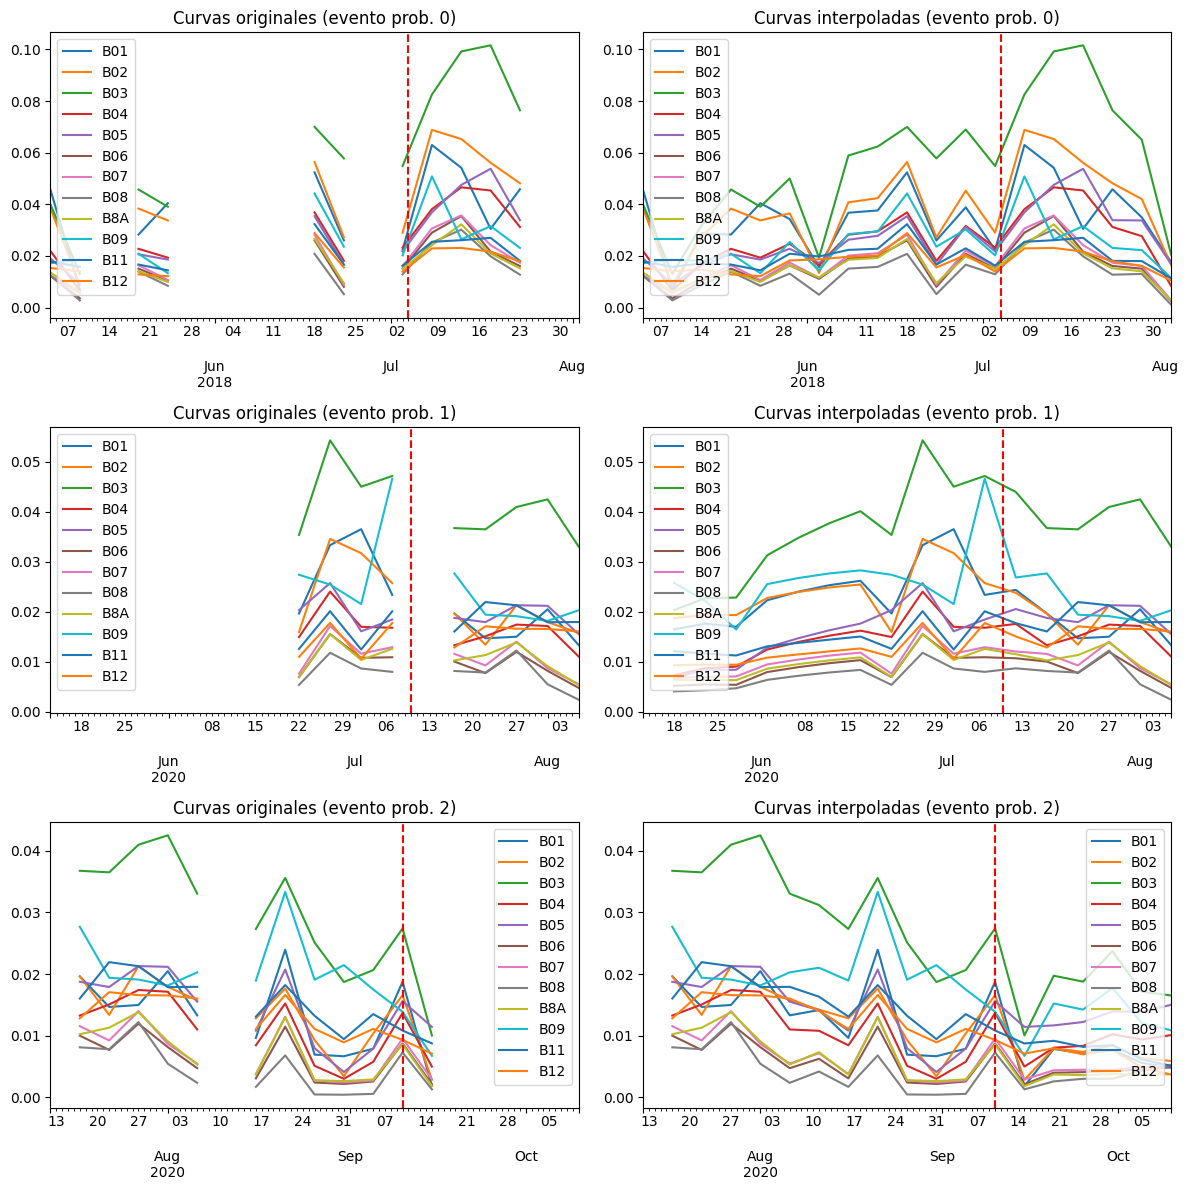

In [ ]:
import matplotlib.pyplot as plt

num_plots = len(curvas)
fig, axes = plt.subplots(num_plots, 2, figsize=(12, 4 * num_plots))

for i in range(num_plots):
    curvas[i].plot(ax=axes[i, 0])  # curvas DataFrame en el subplot izquierdo
    curvas_inter[i].plot(ax=axes[i, 1])  # curvas_inter DataFrame en el subplot derecho

    axes[i, 0].set_title(f"Curvas originales (evento prob. {i})")
    axes[i, 1].set_title(f"Curvas interpoladas (evento prob. {i})")

    # linea vertical indicando la lectura de eutrofización de la CHE
    axes[i, 0].axvline(x=fechas_eventos[i], color='red', linestyle='--')
    axes[i, 1].axvline(x=fechas_eventos[i], color='red', linestyle='--')


plt.tight_layout()
plt.show()

# curvas por banda

In [ ]:
from datetime import datetime
noms_bandas = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12']
intervalos = [('2017-05-04', '2017-08-04'),
              ('2018-05-04', '2018-08-04'),
              ('2019-05-04', '2019-08-04'),
              ('2020-05-04', '2020-08-04'),
              ] # 2 intervalos problemáticos y 2 sin problemas

anyos = ['2017', '2018', '2019', '2020']
listas_fechas = [obtencionFechas(intervalo) for intervalo in intervalos]
curves_dfs = [curvasEnFechas(lista_fechas) for lista_fechas in listas_fechas]

# Se añade columna NDVI = (B8 – B4) / (B8 + B4)
for i in range(len(curves_dfs)):
  curves_dfs[i]['NDVI'] = (curves_dfs[i]['B08'] - curves_dfs[i]['B04']) / (curves_dfs[i]['B08'] + curves_dfs[i]['B04'])

# 'allDates' contiene todas las fechas en el intervalo del 04/05 al 04/08 donde existen imagenes, en cualquiera de los 4 años
all_dates = []
for date_list in listas_fechas:
  for date_str in date_list:
    date_obj = datetime.strptime(date_str, '%Y-%m-%d')
    all_dates.append(date_obj.strftime('1900-%m-%d'))  # Se cambian todas las fechas al año 1900

allDates = list(set(all_dates))  # Eliminar repetidos
allDates.sort()  # Se ordenan

In [ ]:
#Cada DataFrame de esta lista contiene para la misma banda las curvas de las fechas de interés de los 4 años estudiados
graficas = []

# Se hace una copia de los datos obtenidos en la celda anterior para no alterarlos
curves_dfs_copy = [df.copy() for df in curves_dfs]

for df in curves_dfs_copy: # Se cambian los índices de filas para ignorar el año
  df.index = pd.to_datetime(df.index).strftime('1900-%m-%d')

# se crea una lista de dfs que representan las curvas para cada banda, y que comparten índices
for i_banda, banda in enumerate(noms_bandas + ['NDVI']):
  graficas.append(pd.DataFrame(index=allDates))
  for i_df, df in enumerate(curves_dfs_copy):
    graficas[i_banda][anyos[i_df]] = df[banda]

# en todas las gráficas se ignora toda fecha para la que no haya datos en ningún año
graficas = [df.dropna(how='all').copy() for df in graficas]

# se interpola:
orden = 3 # la spline interpolation se hace con polys de este grado
for df in graficas:
  df.index = pd.to_datetime(df.index) # es necesario que el indice sea obj datetime para interpolar
  for anyo in anyos:
    df[anyo] = pd.to_numeric(df[anyo], errors='coerce')

graficas_inter = [df.interpolate(method='spline', order=orden) for df in graficas]

for df in graficas_inter:
  df.index = df.index.strftime('%d/%m') # cambia los row index para ignorar el año


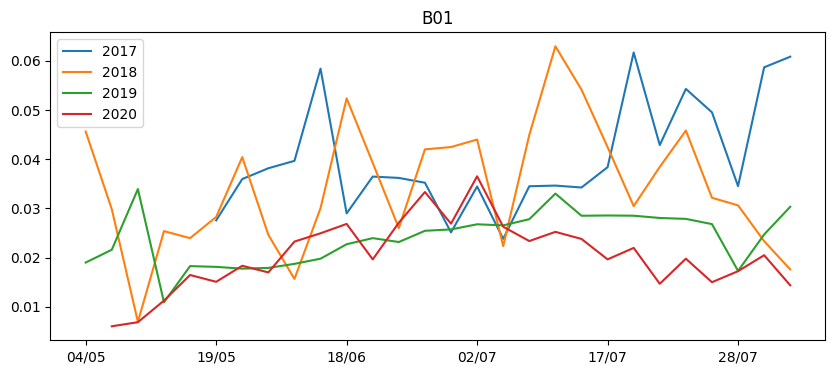

Coeficientes de correlacion para la banda B01
          2017      2018      2019      2020
2017  1.000000 -0.333047  0.202056 -0.335512
2018 -0.333047  1.000000  0.220389  0.488162
2019  0.202056  0.220389  1.000000  0.164431
2020 -0.335512  0.488162  0.164431  1.000000


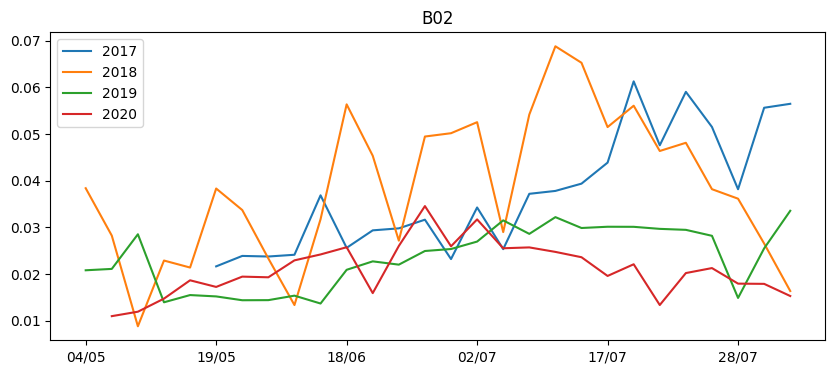

Coeficientes de correlacion para la banda B02
          2017      2018      2019      2020
2017  1.000000  0.118024  0.589873 -0.313407
2018  0.118024  1.000000  0.422211  0.484648
2019  0.589873  0.422211  1.000000  0.141355
2020 -0.313407  0.484648  0.141355  1.000000


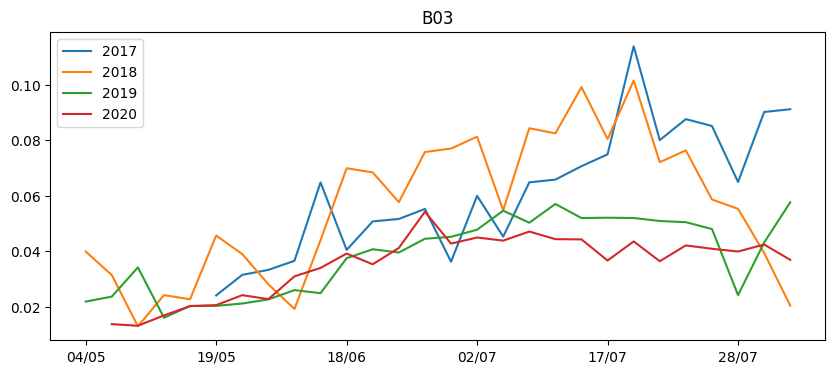

Coeficientes de correlacion para la banda B03
          2017      2018      2019      2020
2017  1.000000  0.348034  0.627054  0.476192
2018  0.348034  1.000000  0.665088  0.756591
2019  0.627054  0.665088  1.000000  0.754064
2020  0.476192  0.756591  0.754064  1.000000


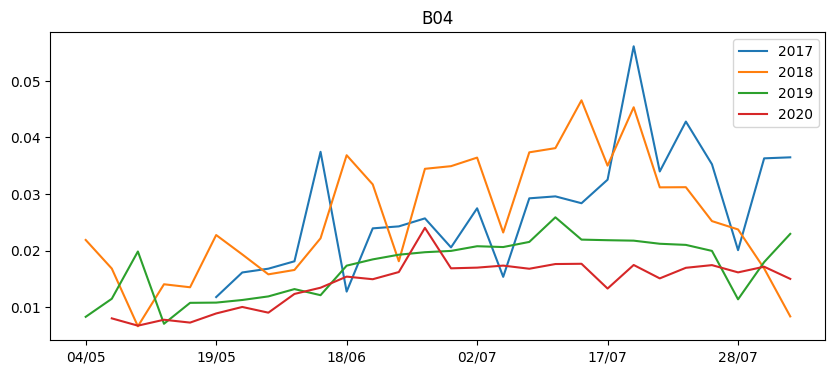

Coeficientes de correlacion para la banda B04
          2017      2018      2019      2020
2017  1.000000  0.269116  0.509322  0.375166
2018  0.269116  1.000000  0.534983  0.651274
2019  0.509322  0.534983  1.000000  0.676940
2020  0.375166  0.651274  0.676940  1.000000


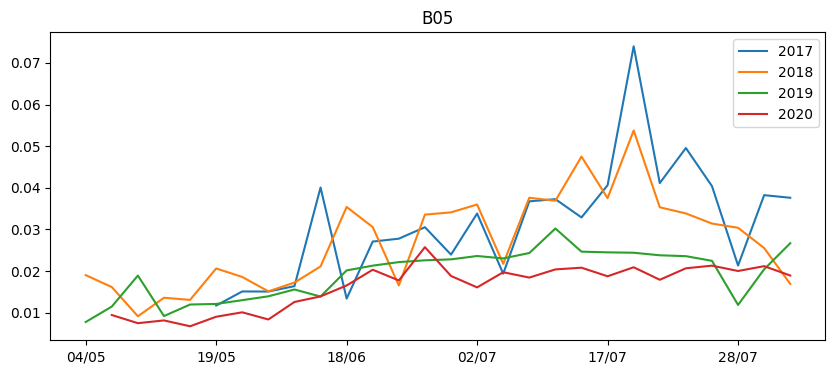

Coeficientes de correlacion para la banda B05
          2017      2018      2019      2020
2017  1.000000  0.615502  0.560568  0.535860
2018  0.615502  1.000000  0.634256  0.721431
2019  0.560568  0.634256  1.000000  0.750638
2020  0.535860  0.721431  0.750638  1.000000


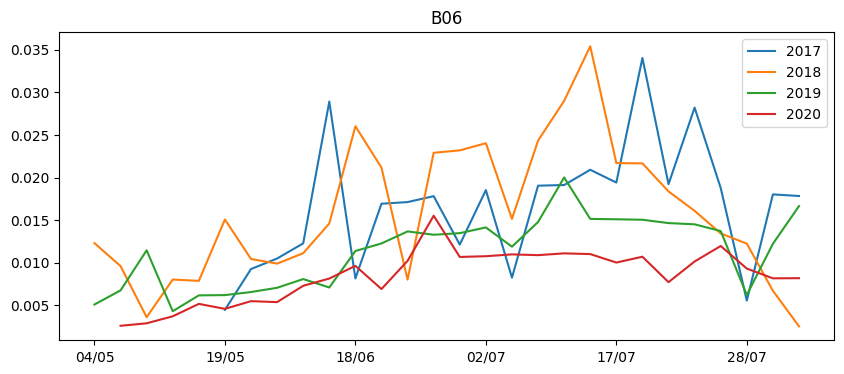

Coeficientes de correlacion para la banda B06
          2017      2018      2019      2020
2017  1.000000  0.208230  0.519157  0.354010
2018  0.208230  1.000000  0.512857  0.612807
2019  0.519157  0.512857  1.000000  0.668081
2020  0.354010  0.612807  0.668081  1.000000


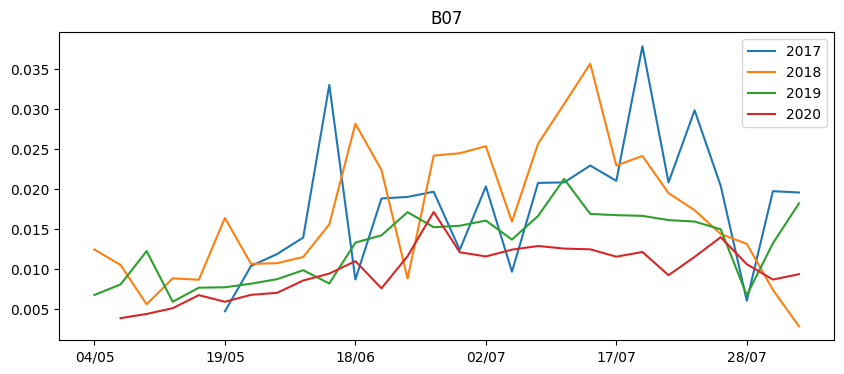

Coeficientes de correlacion para la banda B07
          2017      2018      2019      2020
2017  1.000000  0.205464  0.471176  0.326099
2018  0.205464  1.000000  0.529100  0.606310
2019  0.471176  0.529100  1.000000  0.670691
2020  0.326099  0.606310  0.670691  1.000000


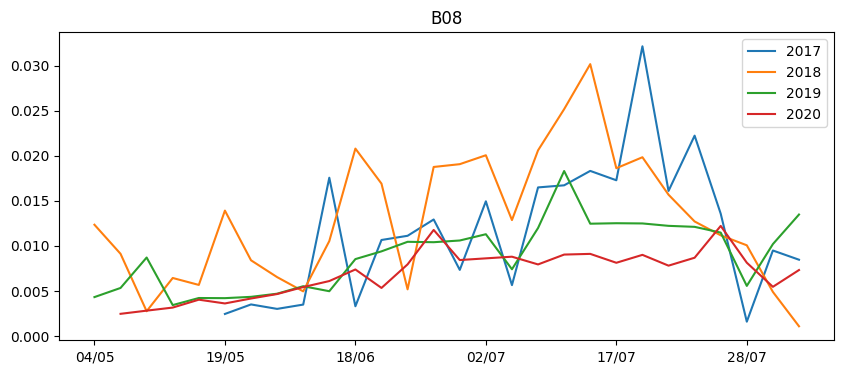

Coeficientes de correlacion para la banda B08
          2017      2018      2019      2020
2017  1.000000  0.455141  0.640995  0.478778
2018  0.455141  1.000000  0.519599  0.544002
2019  0.640995  0.519599  1.000000  0.671991
2020  0.478778  0.544002  0.671991  1.000000


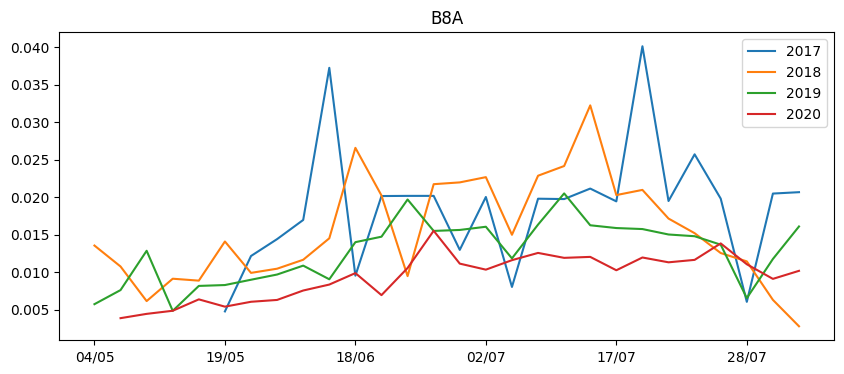

Coeficientes de correlacion para la banda B8A
          2017      2018      2019      2020
2017  1.000000  0.105197  0.345211  0.250113
2018  0.105197  1.000000  0.494880  0.520133
2019  0.345211  0.494880  1.000000  0.653541
2020  0.250113  0.520133  0.653541  1.000000


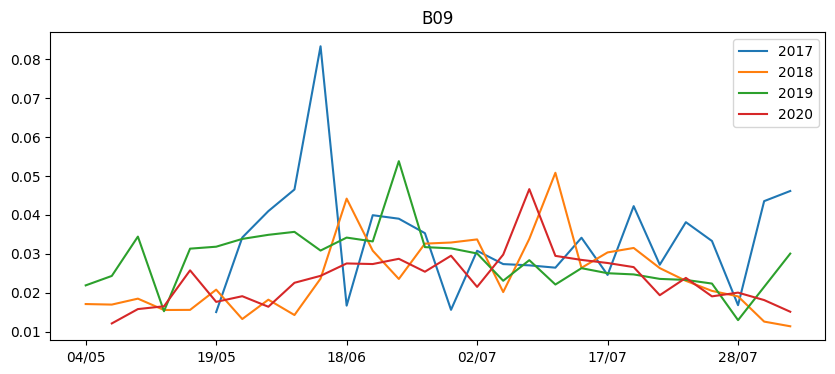

Coeficientes de correlacion para la banda B09
          2017      2018      2019      2020
2017  1.000000 -0.336705  0.206059 -0.166421
2018 -0.336705  1.000000  0.051966  0.598765
2019  0.206059  0.051966  1.000000  0.151889
2020 -0.166421  0.598765  0.151889  1.000000


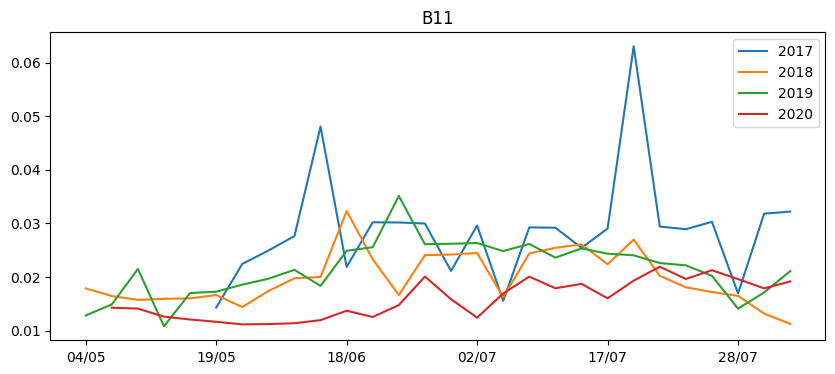

Coeficientes de correlacion para la banda B11
          2017      2018      2019      2020
2017  1.000000  0.216171  0.110167  0.163295
2018  0.216171  1.000000  0.496155  0.117077
2019  0.110167  0.496155  1.000000  0.207263
2020  0.163295  0.117077  0.207263  1.000000


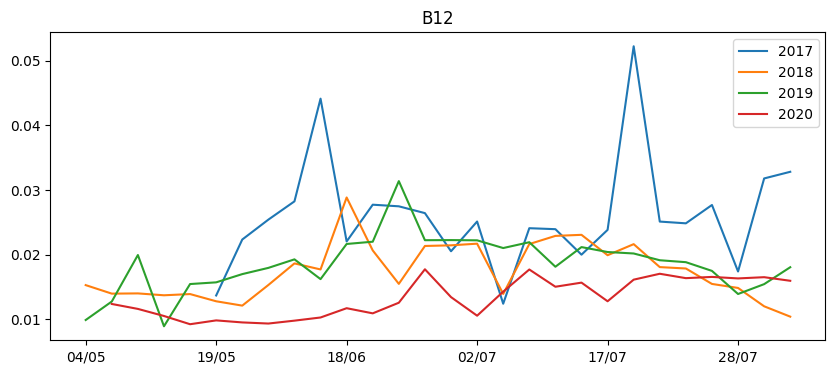

Coeficientes de correlacion para la banda B12
          2017      2018      2019      2020
2017  1.000000  0.065869 -0.016142  0.081288
2018  0.065869  1.000000  0.455102  0.169209
2019 -0.016142  0.455102  1.000000  0.157684
2020  0.081288  0.169209  0.157684  1.000000


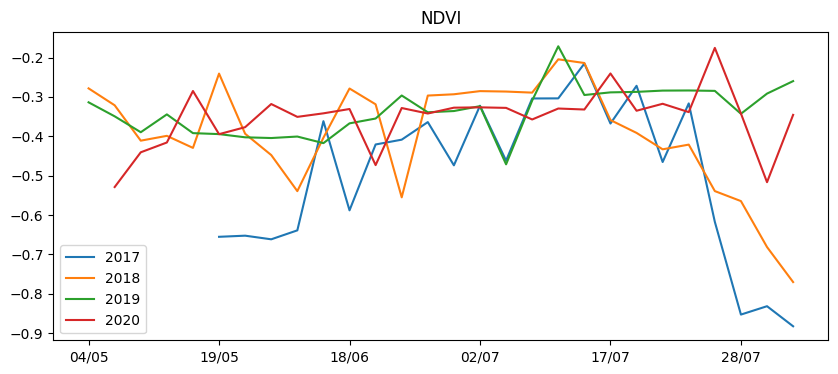

Coeficientes de correlacion para la banda NDVI
          2017      2018      2019      2020
2017  1.000000  0.696942  0.212199  0.225535
2018  0.696942  1.000000 -0.102751  0.012149
2019  0.212199 -0.102751  1.000000  0.163136
2020  0.225535  0.012149  0.163136  1.000000


In [ ]:
for i, titulo in enumerate(noms_bandas + ['NDVI']):
    graficas_inter[i].plot(title=titulo, figsize=(10, 4))
    plt.show()
    print(f'Coeficientes de correlacion para la banda {titulo}')
    print(graficas_inter[i].corr())

# curvas Tªs

In [ ]:
# Cargar la hoja de calculo con los datos de Tª
file_path = './raw_datasets/medidas_elVal.xlsx'

try:
  datosRaw = pd.read_excel(file_path, sheet_name='Datos Val')
except FileNotFoundError:
  print(f"Error: File not found at {file_path}")
except Exception as e:
  print(f"An error occurred: {e}")

# datosRaw es un DF con las columnas de interés
datosRaw = datosRaw[['Fecha', 'Tempe Max', 'Tempe Min']]

Mounted at /content/drive


In [ ]:
intervalos = [('2018-05-04', '2018-08-04'),
              ('2019-05-04', '2019-08-04'),
              ('2020-05-04', '2020-08-04'),
              ('2022-05-04', '2022-08-04')
              ] # 2 intervalos problemáticos y 2 sin problemas

anyos = ['2018', '2019', '2020', '2022']


In [ ]:
dfTemps = datosRaw.copy() #deep copy de los datos crudos porsiacaso

dfTemps = dfTemps.set_index('Fecha')
dfTemps.index = pd.to_datetime(dfTemps.index) # index de dfTemps ahora son las fechas con tipo datetime

graficaTaMedia = pd.DataFrame(columns=anyos) # df con la Tª media normalizada de todos los periodos
graficaTaMinMaxR = pd.DataFrame(columns=anyos) # df con el minMax ratio de todos los periodos
graficaTaMin = pd.DataFrame(columns=anyos) # df con la Tª min d todos los periodos
graficaTaMax = pd.DataFrame(columns=anyos) # df con la Tª Max d todos los periodos

for i, interval in enumerate(intervalos):
  # se obtienen filas de mediciones en las fechas dentro del intervalo
  subset_df = dfTemps[(dfTemps.index >= interval[0]) & (dfTemps.index <= interval[1])].copy()

  # se crea la columna 'Tempe med' con los valores de temperaturas medios normalizados (en [0,1])
  subset_df['Tempe med'] = (subset_df['Tempe Max'] + subset_df['Tempe Min']) / 2
  subset_df['Tempe med (norm)'] = (subset_df['Tempe med'] - subset_df['Tempe med'].min()) / (subset_df['Tempe med'].max() - subset_df['Tempe med'].min())

  subset_df.index = subset_df.index.strftime('%d/%m') # cambia los row index para ignorar el año

  # se almacena resultado de este año en graficaTaMedia
  graficaTaMedia[anyos[i]] = subset_df['Tempe med (norm)']

  # Se crea la columna TaMinMaxRatio, con el ratio TªMax/Tªmin, y se normaliza antes de almacenarse
  subset_df['minMaxR'] = subset_df['Tempe Max'] / subset_df['Tempe Min']
  subset_df['minMaxR (norm)'] = (subset_df['minMaxR'] - subset_df['minMaxR'].min()) / (subset_df['minMaxR'].max() - subset_df['minMaxR'].min())

  # se almacena resultado de este año en graficaTaMinMaxR
  graficaTaMinMaxR[anyos[i]] = subset_df['minMaxR (norm)']


  # se crea y normaliza la columna TaMin (norm)
  subset_df['Tempe min (norm)'] = (subset_df['Tempe Min'] - subset_df['Tempe Min'].min()) / (subset_df['Tempe Min'].max() - subset_df['Tempe Min'].min())

  # se crea y normaliza la columna TaMax (norm)
  subset_df['Tempe Max (norm)'] = (subset_df['Tempe Max'] - subset_df['Tempe Max'].min()) / (subset_df['Tempe Max'].max() - subset_df['Tempe Max'].min())

  # se almacenan resultados de este año en graficaTaMin
  graficaTaMin[anyos[i]] = subset_df['Tempe min (norm)']
  graficaTaMax[anyos[i]] = subset_df['Tempe Max (norm)']


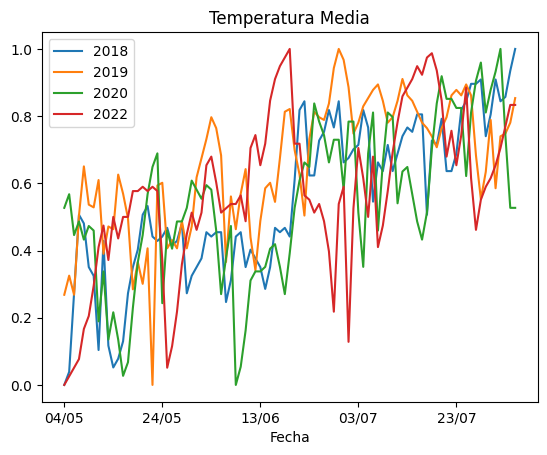

Coeficientes de correlación: Temperatura Media
          2018      2019      2020      2022
2018  1.000000  0.638523  0.673007  0.417149
2019  0.638523  1.000000  0.428147  0.415601
2020  0.673007  0.428147  1.000000  0.133487
2022  0.417149  0.415601  0.133487  1.000000


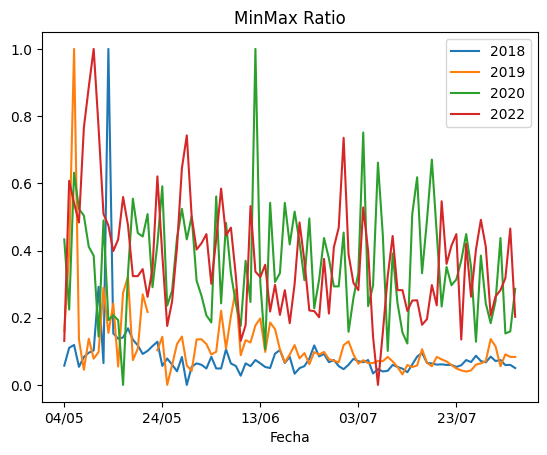

Coeficientes de correlación: MinMax Ratio
          2018      2019      2020      2022
2018  1.000000  0.120772 -0.140486  0.150432
2019  0.120772  1.000000  0.106018  0.191751
2020 -0.140486  0.106018  1.000000 -0.010807
2022  0.150432  0.191751 -0.010807  1.000000


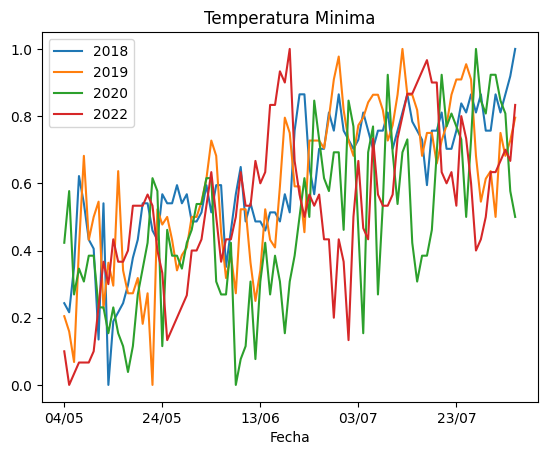

Coeficientes de correlación: Temperatura Minima
          2018      2019      2020      2022
2018  1.000000  0.684253  0.600307  0.433002
2019  0.684253  1.000000  0.486928  0.443798
2020  0.600307  0.486928  1.000000  0.118119
2022  0.433002  0.443798  0.118119  1.000000


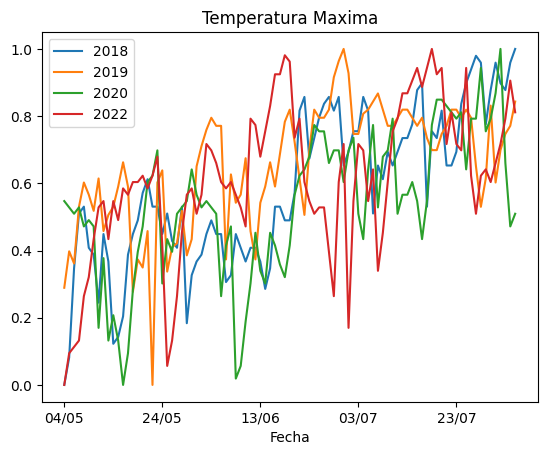

Coeficientes de correlación: Temperatura Maxima
          2018      2019      2020      2022
2018  1.000000  0.548243  0.647473  0.376246
2019  0.548243  1.000000  0.330854  0.368144
2020  0.647473  0.330854  1.000000  0.127299
2022  0.376246  0.368144  0.127299  1.000000


In [ ]:
for df, title in zip([graficaTaMedia, graficaTaMinMaxR, graficaTaMin, graficaTaMax],
                      ['Temperatura Media', 'MinMax Ratio', 'Temperatura Minima', 'Temperatura Maxima']):
    df.plot(title=title)
    plt.show()
    print(f"Coeficientes de correlación: {title}")
    print(df.corr())

# estudio comb. bandas

Primeramente se estudian las combinaciones $B09 \cdot B11$ y $B09 / B11$. El resultado de estas celdas se emplea en posteriores subsecciones de este apartado.

In [6]:
# evalscript para hacer solicitudes a la api de las combinaciones B09*B11 y B09/B11
B09y11ES = '''
//VERSION=3
function evaluatePixel(samples) {
  let val1 = samples.B09/samples.B11
  let val2 = samples.B09*samples.B11
  return [val1, val2];
}

function setup() {
  return {
    input: [{
      bands: [
        "B09",
        "B11",
      ]
    }],
    output: {
      bands: 2,
      sampleType: "FLOAT32"
    }
  }
}
'''

from datetime import datetime
intervalos = [('2018-05-04', '2018-08-04'),
              ('2019-05-04', '2019-08-04'),
              ('2020-05-04', '2020-08-04'),
              ('2022-05-04', '2022-08-04')
              ] # 2 intervalos problemáticos y 2 sin problemas

anyos = ['2018', '2019', '2020', '2022']
listas_fechas = [obtencionFechas(intervalo) for intervalo in intervalos]
curves_dfs = [curvasEnFechas(lista_fechas, rezEvalscript=B09y11ES, noms_bandas=['B09/B11','B09*B11']) for lista_fechas in listas_fechas]


# la lista 'allDates' contiene todas las fechas en el intervalo del 04/05 al 04/08 donde ha existen imagenes, en cualquiera de los 4 años
all_dates = []
for date_list in listas_fechas:
  for date_str in date_list:
    date_obj = datetime.strptime(date_str, '%Y-%m-%d')
    all_dates.append(date_obj.strftime('2000-%m-%d'))  # Se ignora el año cambiando todos los al 2000

allDates = list(set(all_dates))  # Se eliminan repeticiones
allDates.sort()  # Se ordenan

In [8]:
noms_bandas = ['B09/B11','B09*B11']
graficas = [] # lista de df que contienen, para la misma comb. de bandas en el mismo intervalo, las curvas de los 4 años estudiados


curves_dfs_copy = [df.copy() for df in curves_dfs] # se hace una copia de los datos obtenidos para no alterarlos
for df in curves_dfs_copy:
  df.index = pd.to_datetime(df.index).strftime('2000-%m-%d') # cambia los row index para ignorar el año

for i_banda, banda in enumerate(noms_bandas):
  graficas.append(pd.DataFrame(index=allDates)) # cada grafica sera un df con allDates como row index
  for i_df, df in enumerate(curves_dfs_copy):
    graficas[i_banda][anyos[i_df]] = df[banda]


orden = 3 # la spline interpolation se hace con polys de este grado
for df in graficas:
  df.index = pd.to_datetime(df.index)
  for anyo in anyos:
    df[anyo] = pd.to_numeric(df[anyo], errors='coerce')

graficas_B9y11_inter = [df.interpolate(method='spline', order=orden) for df in graficas]

for df in graficas_B9y11_inter:
  df.index = df.index.strftime('%d/%m') # cambia los row index para plottear solo con mes y dia


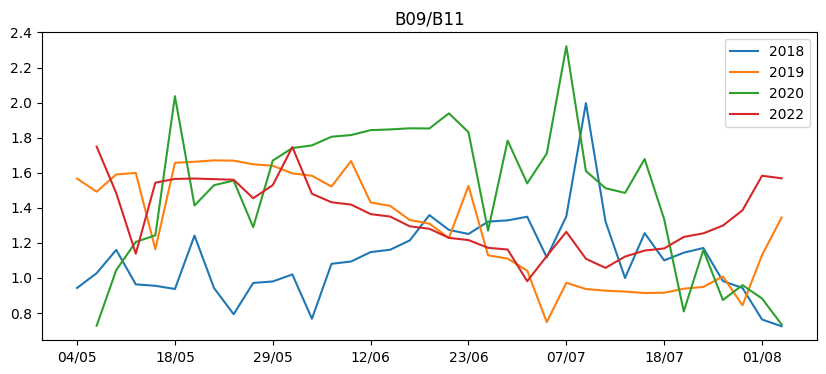

Coeficientes de correlación para la combinación B09/B11
          2018      2019      2020      2022
2018  1.000000 -0.380549  0.350296 -0.594446
2019 -0.380549  1.000000  0.168264  0.661588
2020  0.350296  0.168264  1.000000 -0.201521
2022 -0.594446  0.661588 -0.201521  1.000000


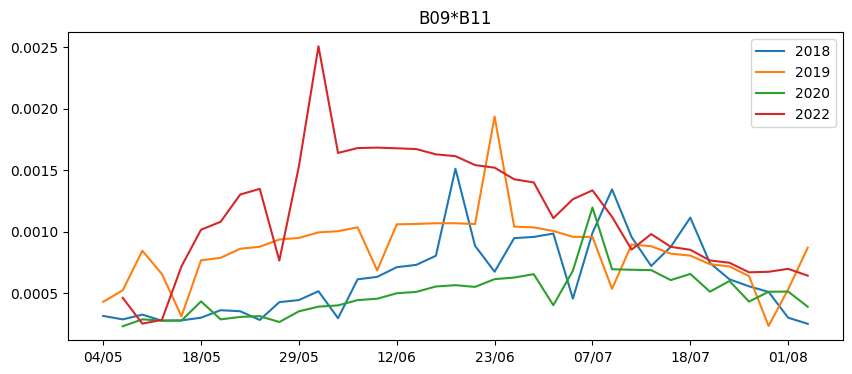

Coeficientes de correlación para la combinación B09*B11
          2018      2019      2020      2022
2018  1.000000  0.282993  0.648922  0.285687
2019  0.282993  1.000000  0.231524  0.549841
2020  0.648922  0.231524  1.000000  0.197090
2022  0.285687  0.549841  0.197090  1.000000


In [ ]:
for i, titulo in enumerate(noms_bandas):
    graficas_B9y11_inter[i].plot(title=titulo, figsize=(10, 4))
    plt.show()
    print(f'Coeficientes de correlación para la combinación {titulo}')
    print(graficas_B9y11_inter[i].corr()) #coef. de correla de Pearson


A continuación se realizan varias pruebas para comprobar si la temperatura minima, máxima, media o el ratio entre mínima y máxima pueden aportar algo a los indicadores ya estudiados.

Cada subapartado puede ser ejecutado independientemente, mientras se hayan ejecutado los primeros apartados de configuración y declaración de funciones útiles y las celdas en este apartado en el que se obtienen las curvas de las combinaciones de bandas B09*B11 y B09/B11 y se importa el dataset de temperaturas del Val.

In [ ]:
# Cargar la hoja de calculo con los datos de Tª
import pandas as pd

file_path = './raw_datasets/medidas_elVal.xlsx'

try:
  datosRaw = pd.read_excel(file_path, sheet_name='Datos Val')
except FileNotFoundError:
  print(f"Error: File not found at {file_path}")
except Exception as e:
  print(f"An error occurred: {e}")

datosRaw = datosRaw[['Fecha', 'Tempe Max', 'Tempe Min']]

Mounted at /content/drive


## curvas comb. bandas y temperaturas medias:

In [ ]:
dfTemps = datosRaw.copy() #deep copy de los datos de Tª crudos porsiacaso

graficas_B9y11 = [df.copy() for df in graficas_B9y11_inter] # deep copy de graficas de combs. de bandas ya interpoladas
# normalizamos valores reflectancia y se quedan en [0,1]
for i, df in enumerate(graficas_B9y11):
    global_min = df.min().min()
    global_max = df.max().max()
    graficas_B9y11[i] = (df - global_min) / (global_max - global_min)

dfTemps = dfTemps.set_index('Fecha')
dfTemps.index = pd.to_datetime(dfTemps.index) # index de dfTemps ahora son las fechas con tipo datetime

# df con la Tª media normalizada de todos los periodos para (únicamente) las fechas en las que habia datos del satelite
graficaTaMedia = pd.DataFrame(columns=anyos)

for i, interval in enumerate(intervalos):
  # se obtienen filas de mediciones de las fechas dentro del intervalo
  subset_df = dfTemps[(dfTemps.index >= interval[0]) & (dfTemps.index <= interval[1])].copy()

  subset_df.index = subset_df.index.strftime('%d/%m') # cambia los row index para ignorar el año
  # se mantienen sólo las mediciones para los dias para los que hay mediciones del satelite
  subset_df = subset_df[subset_df.index.isin(graficas_B9y11[0].index)]

  # se crea y normaliza la columna 'Tempe med'
  subset_df['Tempe med'] = (subset_df['Tempe Max'] + subset_df['Tempe Min']) / 2
  subset_df['Tempe med (norm)'] = (subset_df['Tempe med'] - subset_df['Tempe med'].min()) / (subset_df['Tempe med'].max() - subset_df['Tempe med'].min())

  # se almacena resultado de este año en graficaTaMedia
  graficaTaMedia[anyos[i]] = subset_df['Tempe med (norm)']


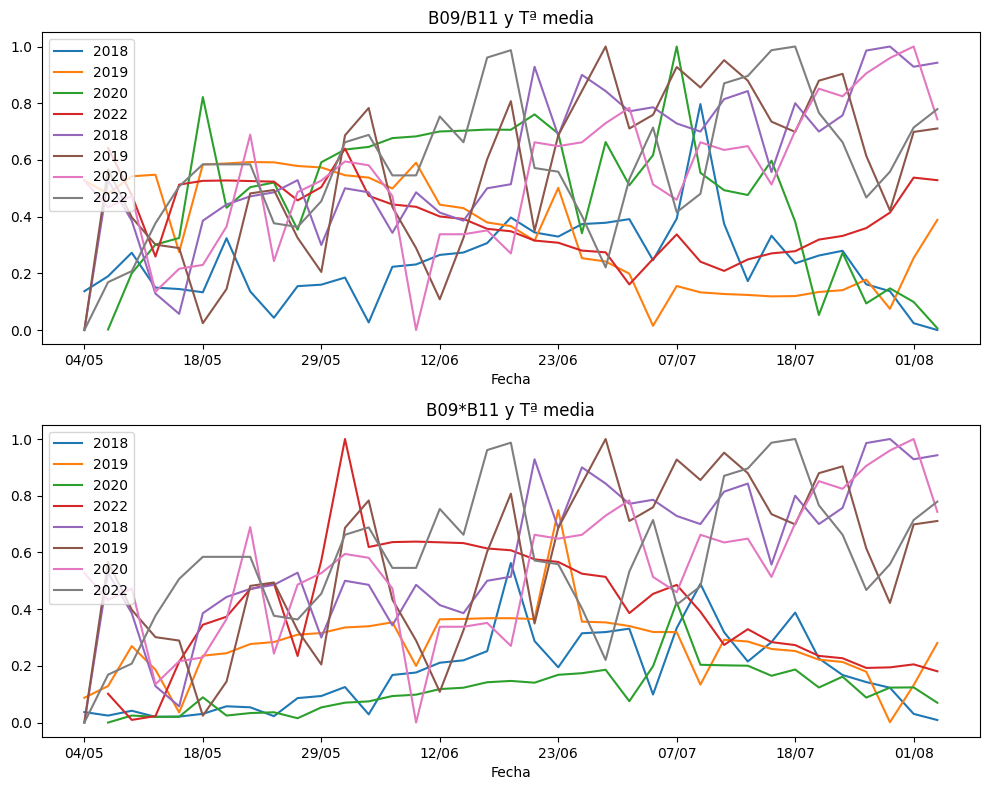

In [ ]:
num_plots = len(graficas_B9y11)
fig, axes = plt.subplots(num_plots, 1, figsize=(10, 4 * num_plots))

for i, titulo in enumerate(noms_bandas):
    graficas_B9y11[i].plot(ax=axes[i])
    graficaTaMedia.plot(ax=axes[i])
    # plot título y leyenda
    axes[i].set_title(titulo+' y Tª media')
    axes[i].legend()


plt.tight_layout()
plt.show()

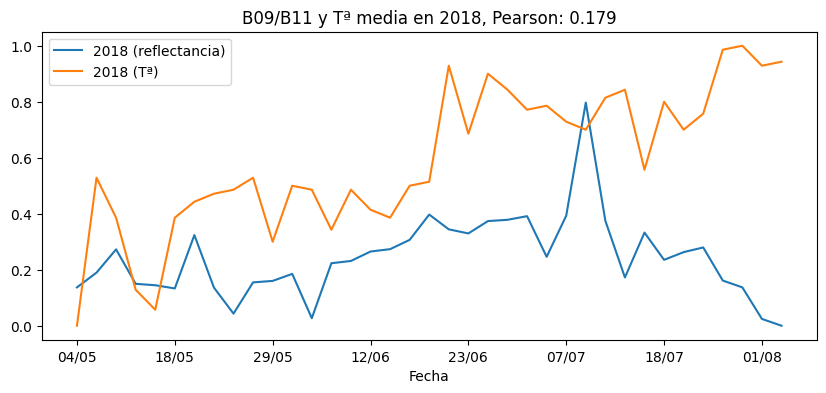

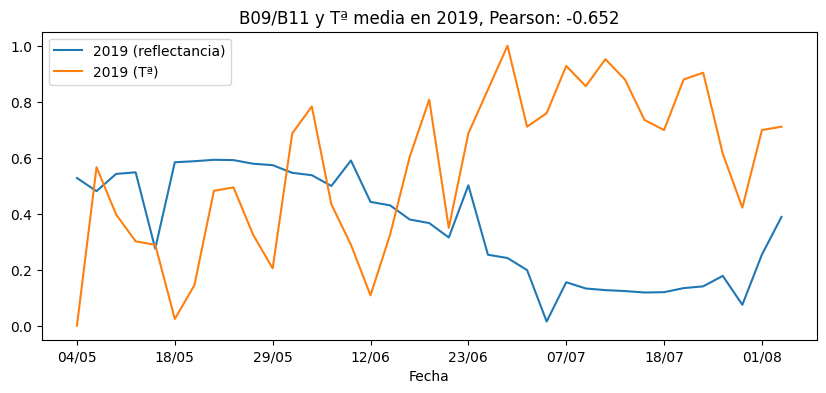

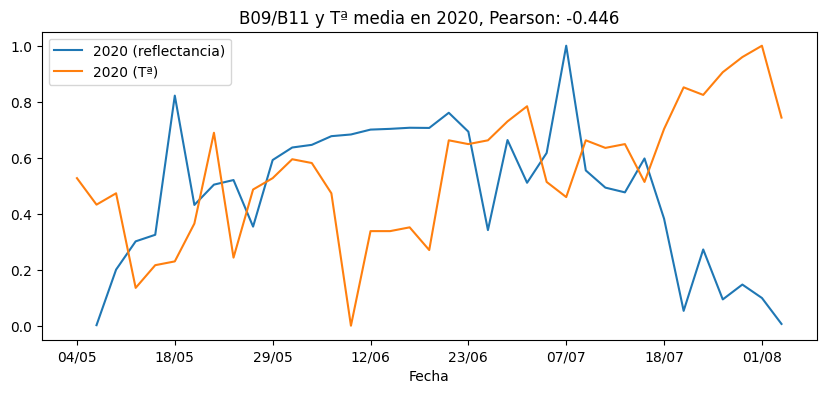

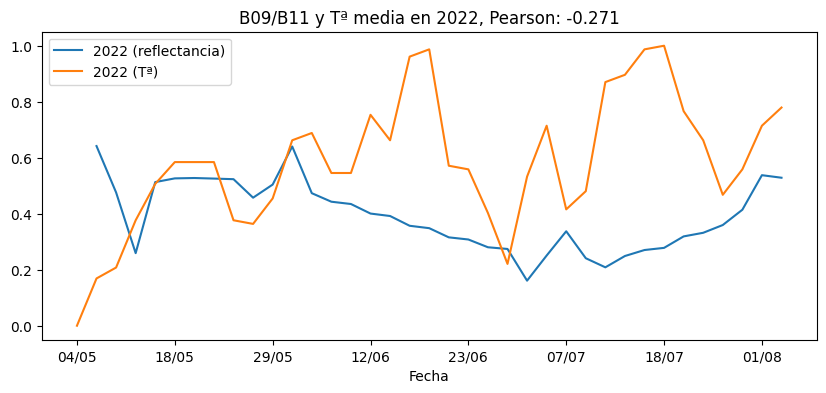

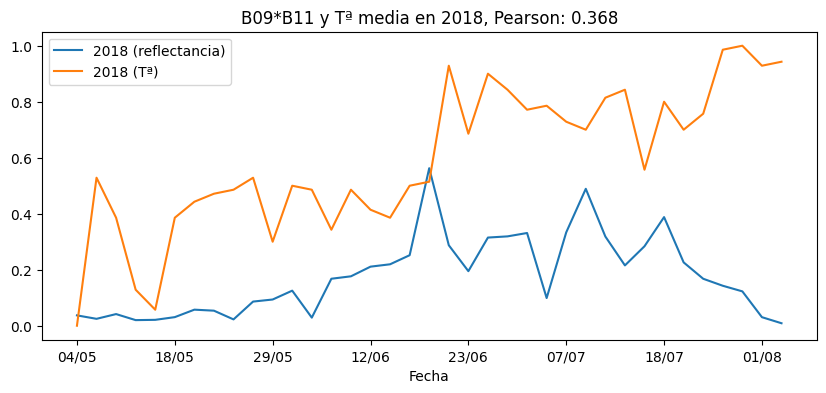

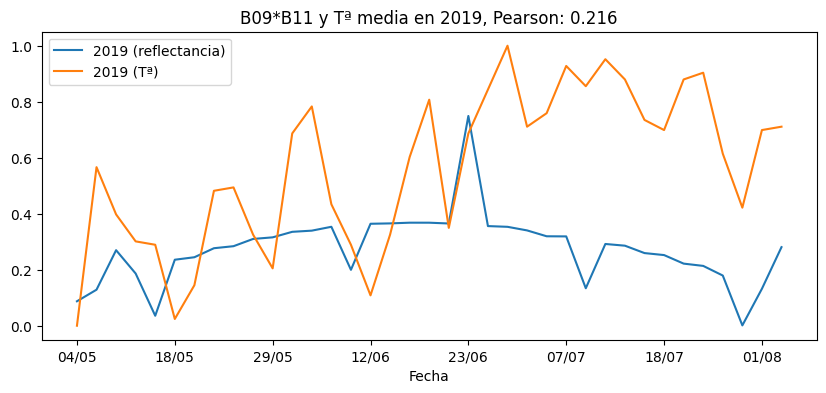

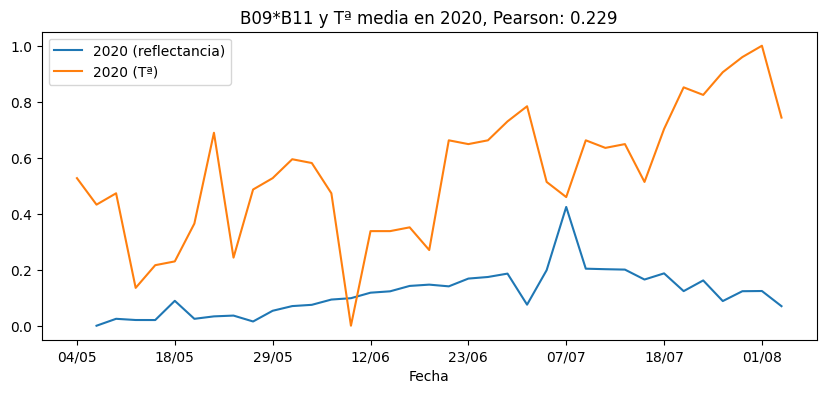

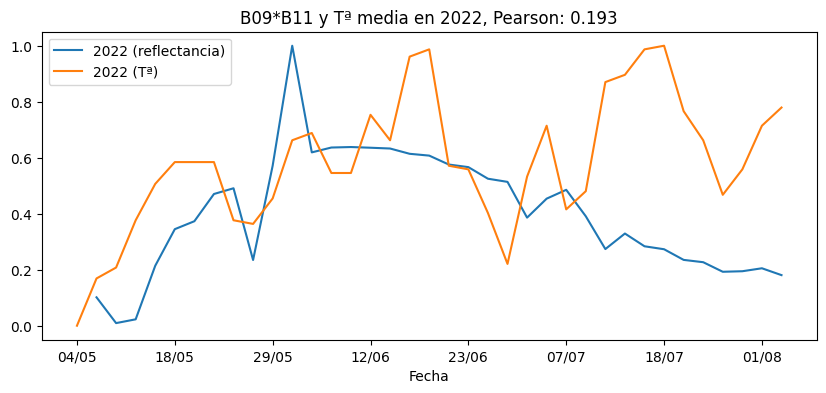

In [ ]:
# plot de cada año individualmente para comparar Tª y reflectancia
for i_comb, nombre_comb in enumerate(noms_bandas):
  curva_combi = graficas_B9y11[i_comb]

  for i, column_name in enumerate(anyos):
      fig, ax = plt.subplots(figsize=(10, 4))
      curva_combi[column_name].plot(ax=ax, label=column_name+' (reflectancia)')
      graficaTaMedia[column_name].plot(ax=ax, label=column_name+' (Tª)')

      curve1 = curva_combi[column_name].values
      curve2 = graficaTaMedia[column_name].values
      mask = ~np.isnan(curve1) & ~np.isnan(curve2) & ~np.isinf(curve1) & ~np.isinf(curve2)

      curve1_clean = curve1[mask]
      curve2_clean = curve2[mask]
      correlation_coefficient = np.corrcoef(curve1_clean, curve2_clean, rowvar=False)[0, 1]

      #Añadimos el coeficiente de correlación al título del gráfico
      plt.title(nombre_comb+' y Tª media en '+column_name+f', Pearson: {correlation_coefficient:.3f}')
      plt.legend()
      plt.show()
      print() # para separar las graficas al plottearlas


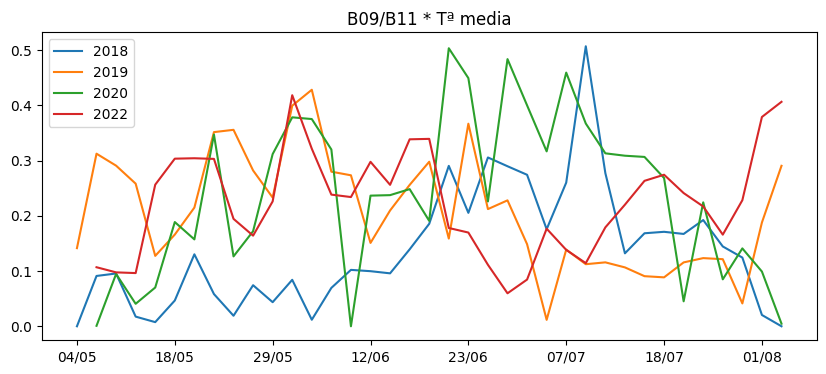

Correlaciones con coef. de Pearson:
          2018      2019      2020      2022
2018  1.000000 -0.376094  0.530511 -0.509613
2019 -0.376094  1.000000 -0.024531  0.216873
2020  0.530511 -0.024531  1.000000 -0.157594
2022 -0.509613  0.216873 -0.157594  1.000000


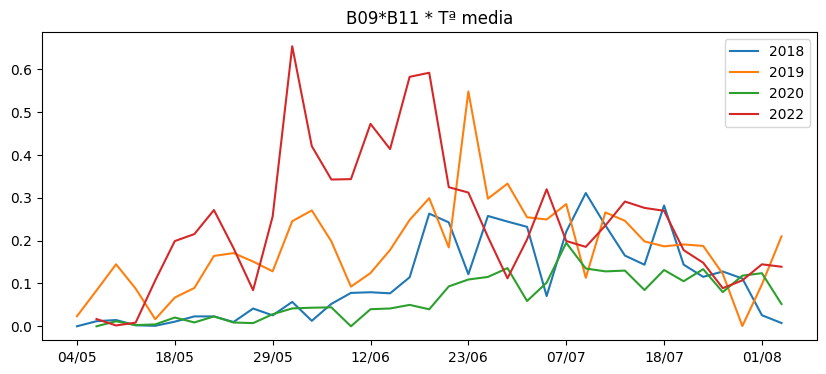

Correlaciones con coef. de Pearson:
          2018      2019      2020      2022
2018  1.000000  0.445345  0.700392  0.158400
2019  0.445345  1.000000  0.411848  0.380608
2020  0.700392  0.411848  1.000000 -0.040381
2022  0.158400  0.380608 -0.040381  1.000000


In [ ]:
# gráficas de combinaciones de bandas * temperaturas
curvasCombsxTemps = []
for i in range(len(graficas_B9y11)):
  curvasCombsxTemps.append(graficas_B9y11[i] * graficaTaMedia)

for i, nom_combi in enumerate(noms_bandas):
    curvasCombsxTemps[i].plot(title=nom_combi+' * Tª media', figsize=(10, 4))
    plt.show()
    print(f'Correlaciones con coef. de Pearson:')
    print(curvasCombsxTemps[i].corr())

## curvas comb. bandas y Tª min/max

In [9]:
dfTemps = datosRaw.copy() #deep copy de los datos de Tª crudos porsiacaso

graficas_B9y11 = [df.copy() for df in graficas_B9y11_inter] # deep copy de graficas de combs. de bandas ya interpoladas
# normalizamos valores reflectancia y se quedan en [0,1]
for i, df in enumerate(graficas_B9y11):
    global_min = df.min().min()
    global_max = df.max().max()
    graficas_B9y11[i] = (df - global_min) / (global_max - global_min)

dfTemps = dfTemps.set_index('Fecha')
dfTemps.index = pd.to_datetime(dfTemps.index) # index de dfTemps ahora son las fechas con tipo datetime


graficaTaMinMaxR = pd.DataFrame(columns=anyos) # df con el minMax ratio de todos los periodos para (únicamente) las fechas en las que habia datos del satelite

for i, interval in enumerate(intervalos):
  # se obtienen filas de mediciones de las fechas dentro del intervalo
  subset_df = dfTemps[(dfTemps.index >= interval[0]) & (dfTemps.index <= interval[1])].copy()

  subset_df.index = subset_df.index.strftime('%d/%m') # cambia los row index para ignorar el año
  # se mantienen sólo las mediciones para los dias para los que hay mediciones del satelite
  subset_df = subset_df[subset_df.index.isin(graficas_B9y11[0].index)]

  # se crea y normaliza la columna TaMinMaxRatio
  subset_df['minMaxR'] = subset_df['Tempe Max'] / subset_df['Tempe Min']
  subset_df['minMaxR (norm)'] = (subset_df['minMaxR'] - subset_df['minMaxR'].min()) / (subset_df['minMaxR'].max() - subset_df['minMaxR'].min())

  # se almacena resultado de este año en graficaTaMinMaxR
  graficaTaMinMaxR[anyos[i]] = subset_df['minMaxR (norm)']


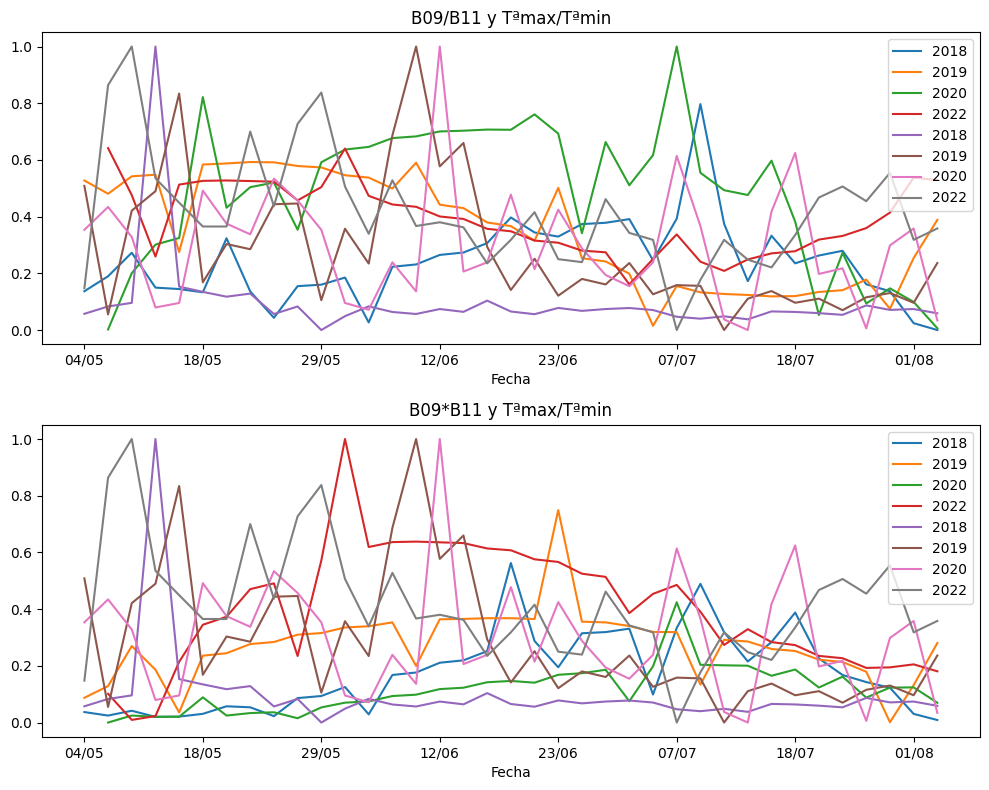

In [10]:
num_plots = len(graficas_B9y11)
fig, axes = plt.subplots(num_plots, 1, figsize=(10, 4 * num_plots))

for i, titulo in enumerate(noms_bandas):
    graficas_B9y11[i].plot(ax=axes[i])
    graficaTaMinMaxR.plot(ax=axes[i])
    axes[i].set_title(titulo+' y Tªmax/Tªmin')
    axes[i].legend()

plt.tight_layout()
plt.show()

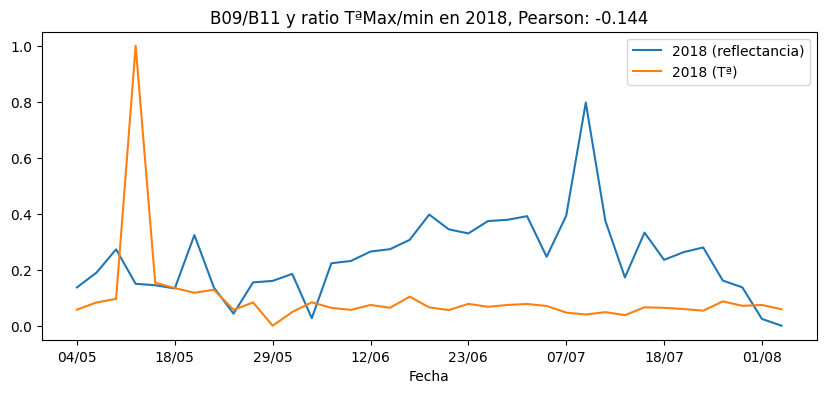

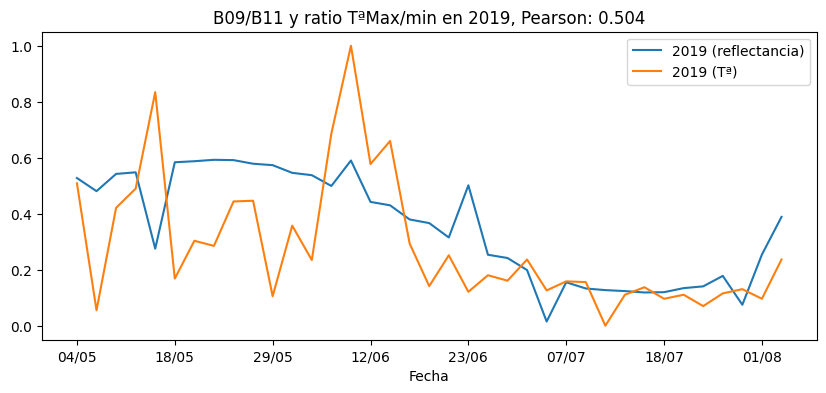

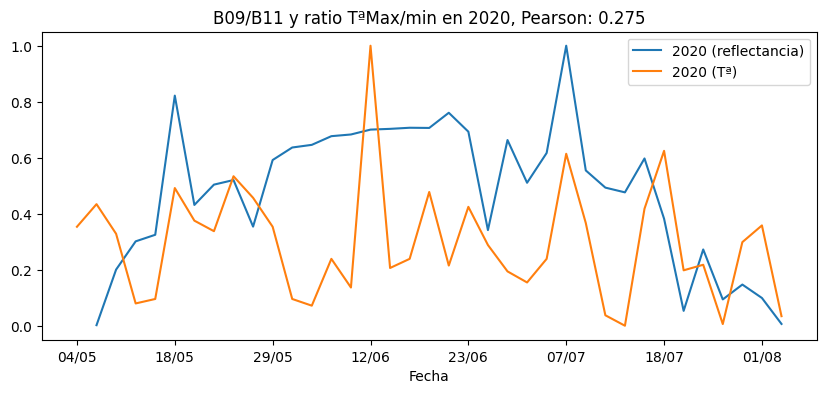

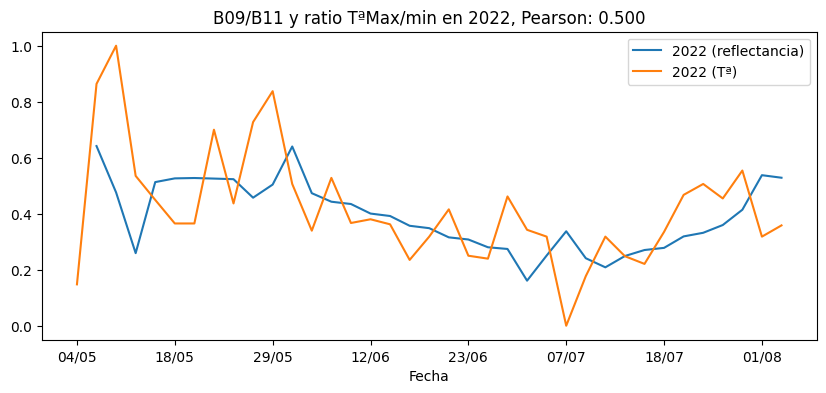

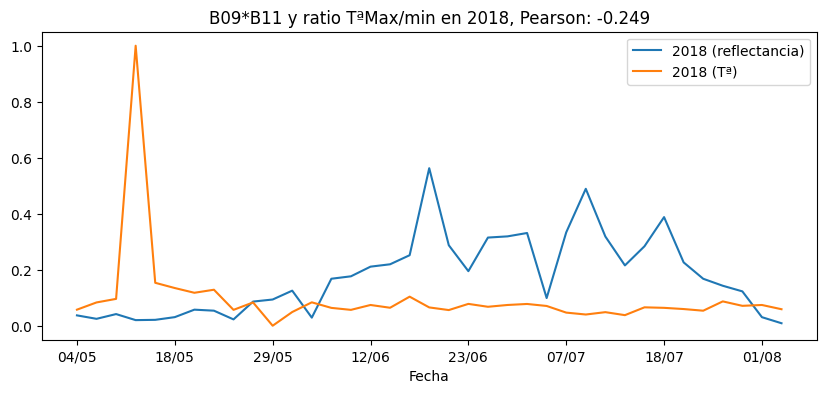

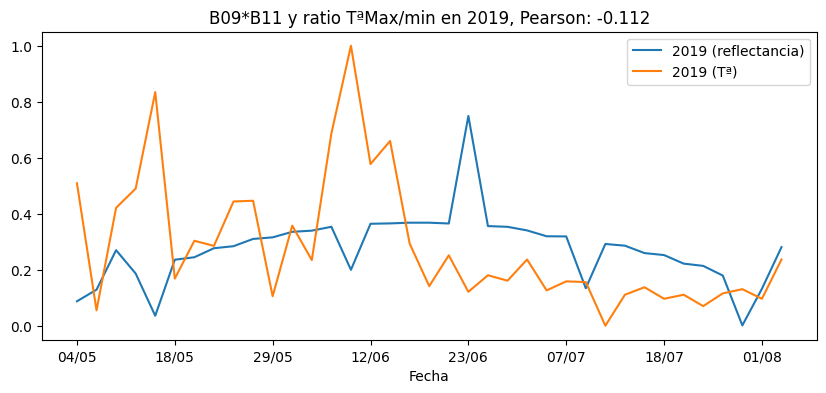

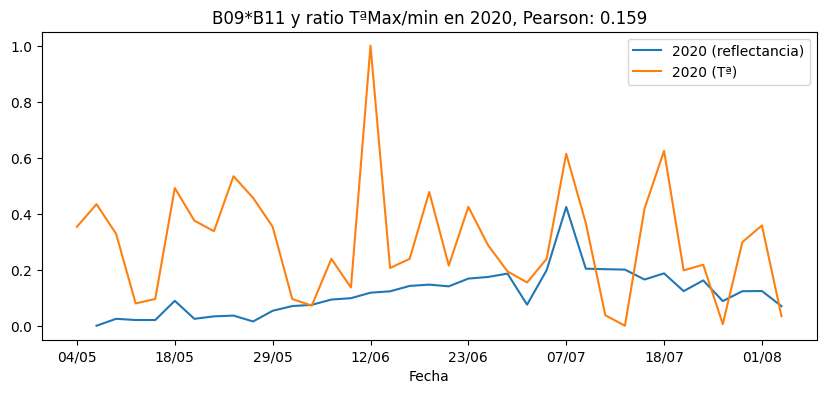

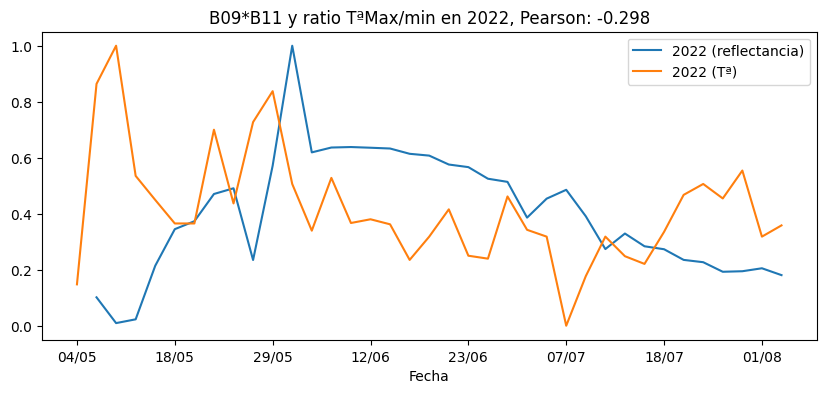

In [11]:
# plot de cada año individualmente para comparar Tª y reflectancia
for i_comb, nombre_comb in enumerate(noms_bandas):
  curva_combi = graficas_B9y11[i_comb]

  for i, column_name in enumerate(anyos):
      fig, ax = plt.subplots(figsize=(10, 4))
      curva_combi[column_name].plot(ax=ax, label=column_name+' (reflectancia)')
      graficaTaMinMaxR[column_name].plot(ax=ax, label=column_name+' (Tª)')

      curve1 = curva_combi[column_name].values
      curve2 = graficaTaMinMaxR[column_name].values
      mask = ~np.isnan(curve1) & ~np.isnan(curve2) & ~np.isinf(curve1) & ~np.isinf(curve2)

      curve1_clean = curve1[mask]
      curve2_clean = curve2[mask]
      correlation_coefficient = np.corrcoef(curve1_clean, curve2_clean, rowvar=False)[0, 1]

      #Añadimos el coeficiente de correlación al título del gráfico
      plt.title(nombre_comb+' y ratio TªMax/min en '+column_name+f', Pearson: {correlation_coefficient:.3f}')
      plt.legend()
      plt.show()
      print() # para separar las graficas al plottearlas


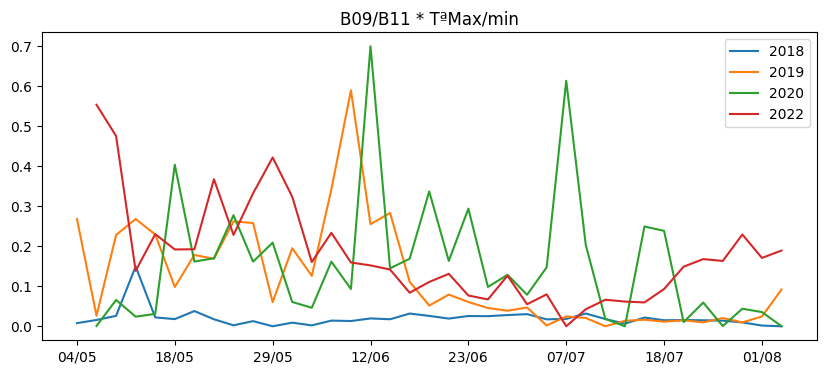

Correlaciones con coef. de Pearson:
          2018      2019      2020      2022
2018  1.000000  0.136009 -0.048689 -0.161838
2019  0.136009  1.000000  0.062611  0.263868
2020 -0.048689  0.062611  1.000000 -0.234830
2022 -0.161838  0.263868 -0.234830  1.000000


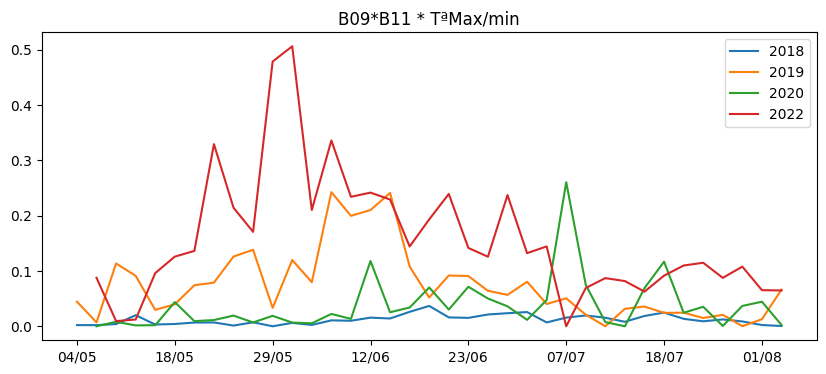

Correlaciones con coef. de Pearson:
          2018      2019      2020      2022
2018  1.000000  0.032197  0.363203 -0.154148
2019  0.032197  1.000000 -0.047911  0.430191
2020  0.363203 -0.047911  1.000000 -0.221650
2022 -0.154148  0.430191 -0.221650  1.000000


In [12]:
# gráficas de combinaciones de bandas * temperaturas
curvasCombsxTemps = []
for i in range(len(graficas_B9y11)):
  curvasCombsxTemps.append(graficas_B9y11[i] * graficaTaMinMaxR)

for i, nom_combi in enumerate(noms_bandas):
  curvasCombsxTemps[i].plot(title=nom_combi+' * TªMax/min', figsize=(10, 4))
  plt.show()
  print(f'Correlaciones con coef. de Pearson:')
  print(curvasCombsxTemps[i].corr())

## curvas B09\*11 con Tªmax y B09*11 con Tªmin

In [ ]:
dfTemps = datosRaw.copy() # deep copy de los datos crudos porsiacaso

dfTemps = dfTemps.set_index('Fecha')
dfTemps.index = pd.to_datetime(dfTemps.index) # index de dfTemps ahora son las fechas con tipo datetime

graficaB09x11 = graficas_B9y11_inter[1].copy() # deepcopy de la curva B09*B11
# normalizamos valores reflectancia y se quedan en [0,1]
global_min = graficaB09x11.min().min()
global_max = graficaB09x11.max().max()
graficaB09x11 = (graficaB09x11 - global_min) / (global_max - global_min)  # Normalize

# dfs con la Tª min y max de todos los periodos para (únicamente) las fechas en las que habia datos del satelite
graficaTaMin = pd.DataFrame(columns=anyos)
graficaTaMax = pd.DataFrame(columns=anyos)

for i, interval in enumerate(intervalos):
  # se obtienen filas de mediciones de las fechas dentro del interval
  subset_df = dfTemps[(dfTemps.index >= interval[0]) & (dfTemps.index <= interval[1])].copy()

  subset_df.index = subset_df.index.strftime('%d/%m') # cambia los row index para ignorar el año
  # se mantienen sólo las mediciones para los dias para los que hay mediciones del satelite
  subset_df = subset_df[subset_df.index.isin(graficaB09x11.index)]

  # created and normalize the TaMin (norm) col
  subset_df['Tempe min (norm)'] = (subset_df['Tempe Min'] - subset_df['Tempe Min'].min()) / (subset_df['Tempe Min'].max() - subset_df['Tempe Min'].min())

  # created and normalize the TaMax (norm) col
  subset_df['Tempe Max (norm)'] = (subset_df['Tempe Max'] - subset_df['Tempe Max'].min()) / (subset_df['Tempe Max'].max() - subset_df['Tempe Max'].min())

  # se almacenan resultados de este año en graficaTaMin
  graficaTaMin[anyos[i]] = subset_df['Tempe min (norm)']
  graficaTaMax[anyos[i]] = subset_df['Tempe Max (norm)']

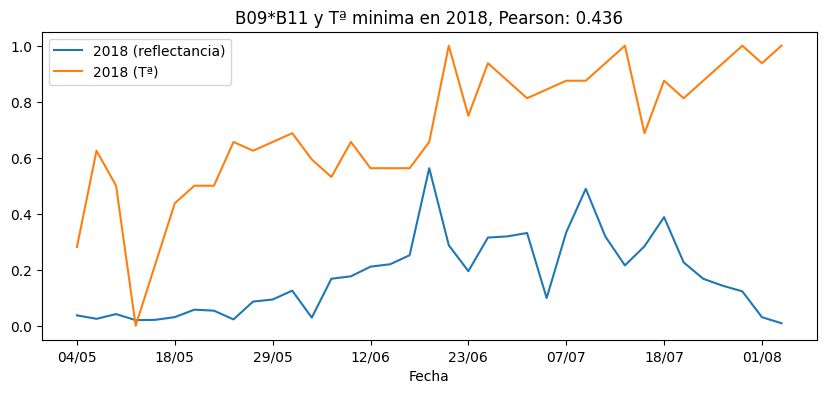

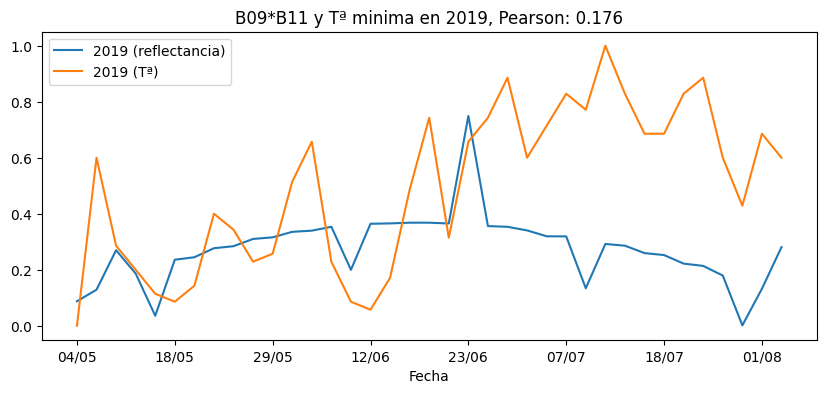

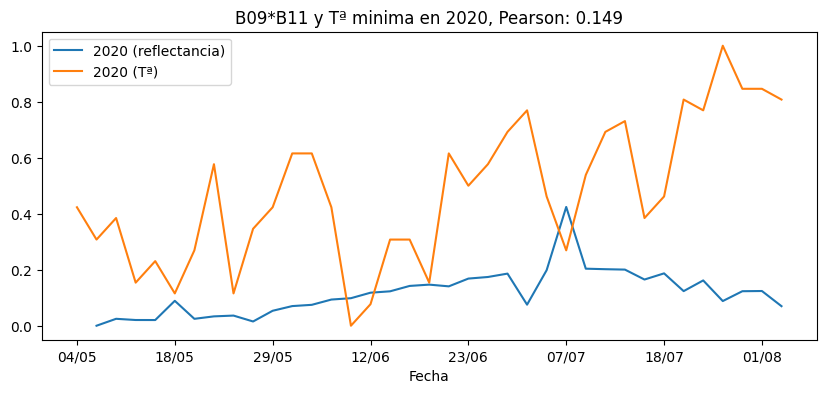

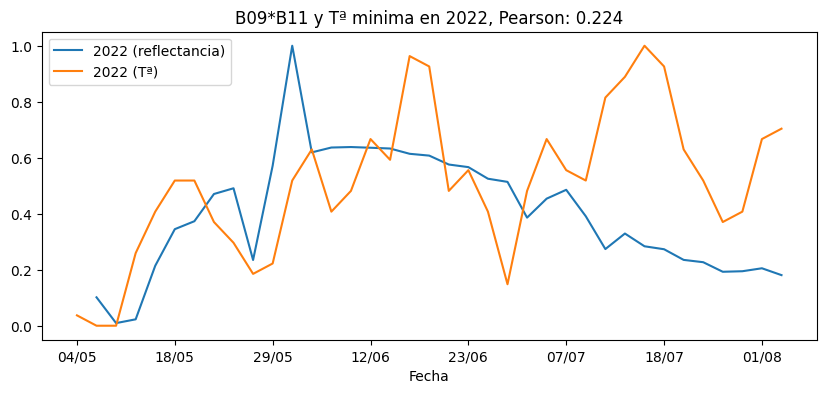

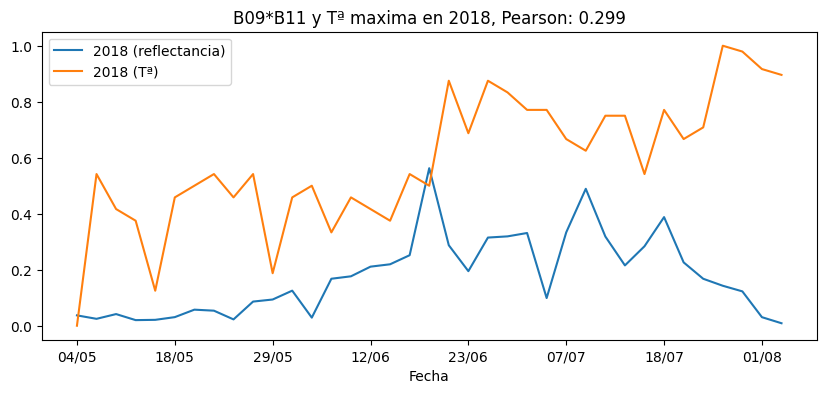

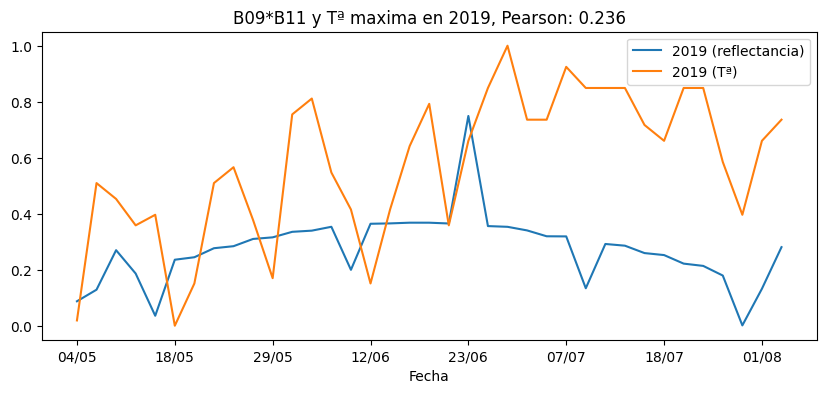

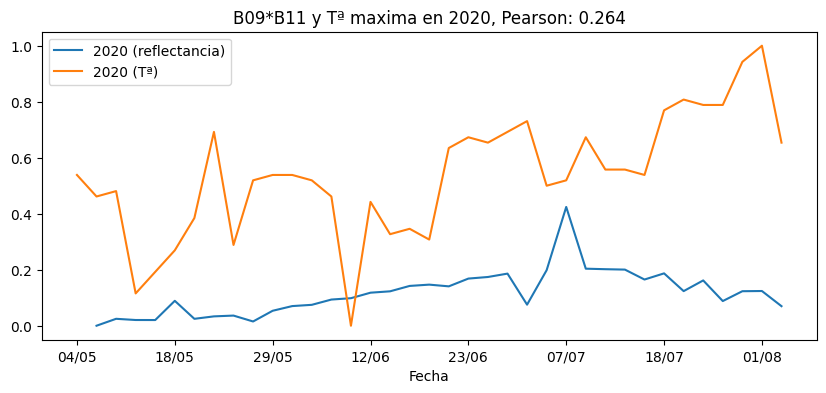

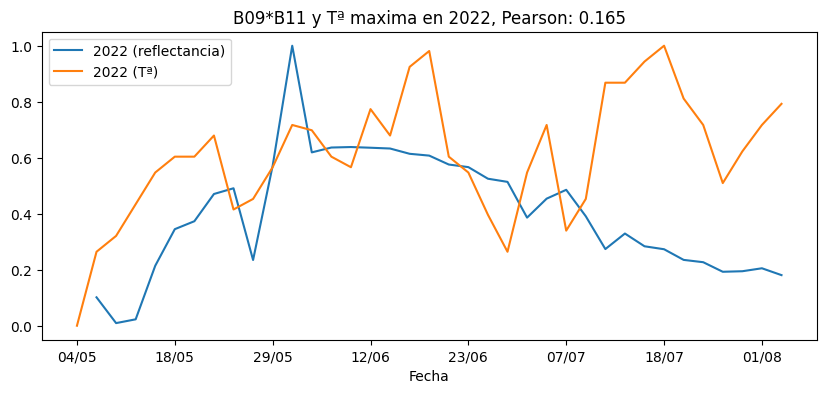

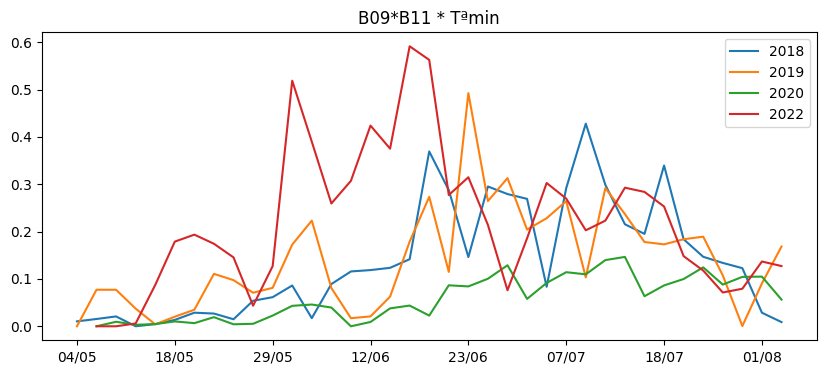

Corr. matrix (coef de Pearson) de B09*11*Tªmin:
          2018      2019      2020      2022
2018  1.000000  0.512810  0.613706  0.310661
2019  0.512810  1.000000  0.576596  0.319119
2020  0.613706  0.576596  1.000000  0.011872
2022  0.310661  0.319119  0.011872  1.000000



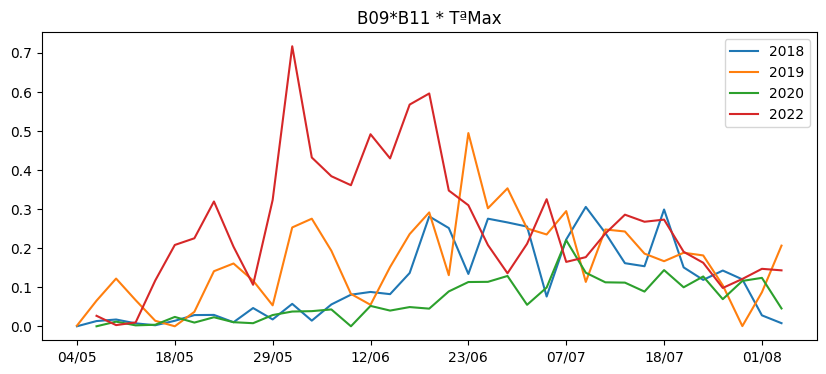

Corr. matrix (coef de Pearson) de B09*11*Tªmax:
          2018      2019      2020      2022
2018  1.000000  0.491520  0.684484  0.116934
2019  0.491520  1.000000  0.450605  0.310510
2020  0.684484  0.450605  1.000000 -0.078688
2022  0.116934  0.310510 -0.078688  1.000000



In [ ]:
# plot de cada año individualmente para comparar Tª min y reflectancia
for i, column_name in enumerate(anyos):
    fig, ax = plt.subplots(figsize=(10, 4))
    graficaB09x11[column_name].plot(ax=ax, label=column_name+' (reflectancia)')
    graficaTaMin[column_name].plot(ax=ax, label=column_name+' (Tª)')

    curve1 = graficaB09x11[column_name].values
    curve2 = graficaTaMin[column_name].values
    mask = ~np.isnan(curve1) & ~np.isnan(curve2) & ~np.isinf(curve1) & ~np.isinf(curve2)

    curve1_clean = curve1[mask]
    curve2_clean = curve2[mask]
    correlation_coefficient = np.corrcoef(curve1_clean, curve2_clean, rowvar=False)[0, 1]

    #Añadimos el coeficiente de correlación al título del gráfico
    plt.title(nombre_comb+' y Tª minima en '+column_name+f', Pearson: {correlation_coefficient:.3f}')
    plt.legend()
    plt.show()
    print() # para separar las graficas al plottearlas


# plot de cada año individualmente para comparar Tª Max y reflectancia
for i, column_name in enumerate(anyos):
    fig, ax = plt.subplots(figsize=(10, 4))
    graficaB09x11[column_name].plot(ax=ax, label=column_name+' (reflectancia)')
    graficaTaMax[column_name].plot(ax=ax, label=column_name+' (Tª)')

    curve1 = graficaB09x11[column_name].values
    curve2 = graficaTaMax[column_name].values
    mask = ~np.isnan(curve1) & ~np.isnan(curve2) & ~np.isinf(curve1) & ~np.isinf(curve2)

    curve1_clean = curve1[mask]
    curve2_clean = curve2[mask]
    correlation_coefficient = np.corrcoef(curve1_clean, curve2_clean, rowvar=False)[0, 1]

    #Añadimos el coeficiente de correlación al título del gráfico
    plt.title(nombre_comb+' y Tª maxima en '+column_name+f', Pearson: {correlation_coefficient:.3f}')
    plt.legend()
    plt.show()
    print() # para separar las graficas al plottearlas


# corr. matrix de combinación B09x11 * Tªmin
curvaCombxTaMin = graficaB09x11 * graficaTaMin
curvaCombxTaMin.plot(title=nom_combi+' * Tªmin', figsize=(10, 4))
plt.show()
print('Corr. matrix (coef de Pearson) de B09*11*Tªmin:')
print(curvaCombxTaMin.corr())
print()

# corr. matrix de combinación B09x11 * Tªmax
curvaCombxTaMax = graficaB09x11 * graficaTaMax
curvaCombxTaMax.plot(title=nom_combi+' * TªMax', figsize=(10, 4))
plt.show()
print('Corr. matrix (coef de Pearson) de B09*11*Tªmax:')
print(curvaCombxTaMax.corr())
print()